In [1]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
# numpy and pandas for data manipulation

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import seaborn as sns
import plotly.express as px


from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()




Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [ ]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')


cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)


y_train_int = y_train.astype(int)

In [3]:
X_train.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Surname_tfidf_0', 'Surname_tfidf_1', 'Surname_tfidf_2',
       'Sur_Geo_Gend_Sal_tfidf_0', 'Sur_Geo_Gend_Sal_tfidf_1',
       'Sur_Geo_Gend_Sal_tfidf_2'],
      dtype='object')

# Generate WOE Features via KMeans Clustering


### **General Idea / Purpose:**

This function creates **new numerical features** from existing numerical columns by:

1. **Clustering each numerical feature** using KMeans to group similar values.
2. **Computing Weight of Evidence (WOE)** for each cluster based on the target variable.
3. **Mapping the WOE values** back to train and test sets as new features.
4. Optionally **evaluating each generated feature** using cross-validated ROC AUC to gauge its predictive strength.
5. Returning the new WOE features for train and test, ready to be added to a model.

**Key points:**

* Focuses purely on **model improvement**, not interpretability.
* Works with any list of numerical features.
* Automatically handles missing values and scales features before clustering.
* Returns the names of the new features for easy integration into downstream pipelines.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from prettytable import PrettyTable

def create_cluster_woe_features(X_train, y_train, X_test, num_features, n_clusters=5, cv_splits=5, verbose=True):
    """
    Generate WOE features based on clustering numerical features.

    Parameters:
    -----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Target variable for training.
    X_test : pd.DataFrame
        Test features.
    num_features : list
        List of numerical features to transform.
    n_clusters : int, default=5
        Number of clusters per feature.
    cv_splits : int, default=5
        Number of CV folds for evaluating each feature.
    verbose : bool, default=True
        Whether to print a PrettyTable of feature CV scores.

    Returns:
    --------
    X_train_woe_final : pd.DataFrame
        Training set with new WOE features.
    X_test_woe_final : pd.DataFrame
        Test set with new WOE features.
    woe_feature_names : list
        List of names of new WOE features.
    """
    
    X_train_feat = X_train.copy()
    X_test_feat = X_test.copy()
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    
    overall_best_score = -np.inf
    overall_best_col = None
    woe_feature_names = []

    table = PrettyTable()
    table.field_names = ['Feature', 'Generated Feature', 'CV ROC AUC']

    for feature in num_features:
        # Fill NaNs with median
        X_train_col = X_train[[feature]].fillna(X_train[feature].median())
        X_test_col = X_test[[feature]].fillna(X_train[feature].median())
        
        # Standardize before clustering
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_col)
        X_test_scaled = scaler.transform(X_test_col)
        
        # KMeans clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        train_labels = kmeans.fit_predict(X_train_scaled)
        test_labels = kmeans.predict(X_test_scaled)
        
        cluster_col = f"{feature}_cluster"
        X_train_feat[cluster_col] = train_labels
        X_test_feat[cluster_col] = test_labels
        
        # Compute WOE per cluster
        df_temp = X_train_feat[[cluster_col]].copy()
        df_temp['target'] = y_train.reset_index(drop=True)
        grouped = df_temp.groupby(cluster_col)['target'].agg(['sum','count'])
        grouped['non_event'] = grouped['count'] - grouped['sum']
        total_event = grouped['sum'].sum()
        total_non_event = grouped['non_event'].sum()
        eps = 1e-5
        woe_map = {}
        for cluster, row in grouped.iterrows():
            event_dist = row['sum'] / total_event if total_event != 0 else eps
            non_event_dist = row['non_event'] / total_non_event if total_non_event != 0 else eps
            woe_map[cluster] = np.log((event_dist + eps) / (non_event_dist + eps))
        
        # Map WOE to train & test
        woe_col = f"{feature}_cluster_WOE_V0"
        X_train_feat[woe_col] = X_train_feat[cluster_col].map(woe_map)
        X_test_feat[woe_col] = X_test_feat[cluster_col].map(woe_map).fillna(0)
        woe_feature_names.append(woe_col)
        
        # Evaluate CV ROC AUC
        X_temp = X_train_feat[[woe_col]].to_numpy()
        y_temp = y_train.to_numpy()
        auc_scores = []
        for train_idx, val_idx in kf.split(X_temp):
            X_tr, X_val = X_temp[train_idx], X_temp[val_idx]
            y_tr, y_val = y_temp[train_idx], y_temp[val_idx]
            model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.02, max_depth=6, random_state=42)
            model.fit(X_tr, y_tr)
            preds = model.predict_proba(X_val)[:,1]
            auc_scores.append(roc_auc_score(y_val, preds))
        mean_auc = np.mean(auc_scores)
        
        if mean_auc > overall_best_score:
            overall_best_score = mean_auc
            overall_best_col = woe_col
        
        table.add_row([feature, woe_col, round(mean_auc,5)])
        # Drop cluster column
        X_train_feat.drop(columns=[cluster_col], inplace=True)
        X_test_feat.drop(columns=[cluster_col], inplace=True)
    
    # Impute any missing values
    imputer = SimpleImputer(strategy='mean')
    X_train_woe_final = pd.DataFrame(imputer.fit_transform(X_train_feat[woe_feature_names]), columns=woe_feature_names, index=X_train_feat.index)
    X_test_woe_final = pd.DataFrame(imputer.transform(X_test_feat[woe_feature_names]), columns=woe_feature_names, index=X_test_feat.index)
    
    if verbose:
        print(table)
        print("Overall best feature:", overall_best_col)
        print("Overall best CV ROC AUC:", round(overall_best_score,5))
    
    return X_train_woe_final, X_test_woe_final, woe_feature_names

In [4]:
X_train_woe, X_test_woe, woe_cols = create_cluster_woe_features(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    num_features=num_cols,
    n_clusters=5
)

+--------------------------+--------------------------------------+------------+
|         Feature          |          Generated Feature           | CV ROC AUC |
+--------------------------+--------------------------------------+------------+
|       CreditScore        |       CreditScore_cluster_WOE        |  0.51979   |
|           Age            |           Age_cluster_WOE            |  0.73767   |
|          Tenure          |          Tenure_cluster_WOE          |  0.51864   |
|         Balance          |         Balance_cluster_WOE          |  0.59024   |
|      NumOfProducts       |      NumOfProducts_cluster_WOE       |  0.74675   |
|        HasCrCard         |        HasCrCard_cluster_WOE         |  0.51168   |
|      IsActiveMember      |      IsActiveMember_cluster_WOE      |  0.62868   |
|     EstimatedSalary      |     EstimatedSalary_cluster_WOE      |  0.51536   |
|     Surname_tfidf_0      |     Surname_tfidf_0_cluster_WOE      |  0.50992   |
|     Surname_tfidf_1      |

# clustering + WOE encoding on numerical features

**Clustering numerical features:**
- If your numerical features are continuous (like Age, Spending amounts, etc.), you can group similar values into “bins” using clustering (like KMeans).
- This reduces noise and captures patterns between ranges of numbers, rather than treating every single number as unique.

**WOE (Weight of Evidence) encoding:**
- After binning, WOE converts each group/bin into a number based on how predictive it is of the target.
- Helps models like Logistic Regression that benefit from monotonic relationships between features and the target.

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# -----------------------------
# Step 0: Setup
# -----------------------------
num_features = num_cols  # numerical features
n_clusters = 5           # number of clusters

# Make copies
X_train_woe = X_train.copy()
X_test_woe = X_test.copy()

# -----------------------------
# Step 1: Cluster each numerical feature
# -----------------------------
cluster_models = {}

for feature in num_features:
    # Fill NaNs with median
    X_feat_train = X_train[[feature]].fillna(X_train[feature].median())
    X_feat_test = X_test[[feature]].fillna(X_train[feature].median())
    
    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    X_train_woe[f'{feature}_cluster'] = kmeans.fit_predict(X_feat_train)
    X_test_woe[f'{feature}_cluster'] = kmeans.predict(X_feat_test)
    
    cluster_models[feature] = kmeans

# -----------------------------
# Step 2: Compute WOE function
# -----------------------------
def compute_woe(train_df, feature_cluster, y_train):
    eps = 1e-5
    woe_dict = {}
    
    if isinstance(y_train, pd.DataFrame):
        y_train = y_train.iloc[:, 0]
    
    df = train_df.copy()
    df['target'] = y_train.reset_index(drop=True)
    
    grouped = df.groupby(feature_cluster)['target'].agg(['sum','count'])
    grouped['non_event'] = grouped['count'] - grouped['sum']
    
    total_event = grouped['sum'].sum()
    total_non_event = grouped['non_event'].sum()
    
    for cluster, row in grouped.iterrows():
        event_dist = row['sum'] / total_event if total_event != 0 else eps
        non_event_dist = row['non_event'] / total_non_event if total_non_event != 0 else eps
        woe_dict[cluster] = np.log((event_dist + eps) / (non_event_dist + eps))
    
    return woe_dict

# -----------------------------
# Step 3: Map WOE to train & test
# -----------------------------
for feature in num_features:
    cluster_col = f'{feature}_cluster'
    woe_map = compute_woe(X_train_woe, cluster_col, y_train)
    
    X_train_woe[f'{feature}_woe'] = X_train_woe[cluster_col].map(woe_map)
    X_test_woe[f'{feature}_woe'] = X_test_woe[cluster_col].map(woe_map).fillna(0)

# -----------------------------
# Step 4: Impute numerical features
# -----------------------------
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train[num_cols]), columns=num_cols)
X_test_imputed = pd.DataFrame(imputer.transform(X_test[num_cols]), columns=num_cols)

woe_features = [f'{f}_woe' for f in num_features]
X_train_woe_imputed = pd.DataFrame(imputer.fit_transform(X_train_woe[woe_features]), columns=woe_features)
X_test_woe_imputed = pd.DataFrame(imputer.transform(X_test_woe[woe_features]), columns=woe_features)

# -----------------------------
# Step 5: Optional CV to check model performance on train only
# -----------------------------
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
    # Original features CV
    cv_orig = cross_val_score(model, X_train_imputed, y_train, cv=5, scoring='accuracy')
    # WOE features CV
    cv_woe = cross_val_score(model, X_train_woe_imputed, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'CV Accuracy Original': cv_orig.mean(),
        'CV Accuracy WOE': cv_woe.mean()
    })

# -----------------------------
# Step 6: Results
# -----------------------------
pd.DataFrame(results)


,Model,CV Accuracy Original,CV Accuracy WOE
0,RandomForest,0.812573,0.812579
1,SVM,0.814801,0.813684


comparing each original numerical feature with its WOE-transformed version in terms of predictive power.

In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# Step 0: Setup
# -----------------------------
num_features = num_cols  # numerical features
woe_features = [f'{f}_woe' for f in num_features]

# -----------------------------
# Step 1: Impute missing values
# -----------------------------
# Original features
imputer_orig = SimpleImputer(strategy='mean')
X_train_orig = pd.DataFrame(imputer_orig.fit_transform(X_train[num_features]), columns=num_features, index=X_train.index)

# WOE features
imputer_woe = SimpleImputer(strategy='mean')
X_train_woe_imp = pd.DataFrame(
    imputer_woe.fit_transform(X_train_woe[woe_features].fillna(0)),
    columns=woe_features,
    index=X_train.index
)

# -----------------------------
# Step 2: Model and cross-validation
# -----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
results = []

for orig_f, woe_f in zip(num_features, woe_features):
    # CV on original feature
    scores_orig = cross_val_score(
        model,
        X_train_orig[[orig_f]],
        y_train,
        cv=5,
        scoring='accuracy'
    )
    
    # CV on WOE feature
    scores_woe = cross_val_score(
        model,
        X_train_woe_imp[[woe_f]],
        y_train,
        cv=5,
        scoring='accuracy'
    )
    
    results.append({
        'Original Feature': orig_f,
        'Original Accuracy (CV)': scores_orig.mean(),
        'Transformed Feature': woe_f,
        'Transformed Accuracy (CV)': scores_woe.mean()
    })

# -----------------------------
# Step 3: Show results
# -----------------------------
df_results = pd.DataFrame(results)
df_results


,Original Feature,Original Accuracy (CV),Transformed Feature,Transformed Accuracy (CV)
0,Pclass,0.665614,Pclass_woe,0.665614
1,Sex,0.786737,Sex_woe,0.786737
2,Age,0.627399,Age_woe,0.616163
3,SibSp,0.627437,SibSp_woe,0.633024
4,Parch,0.613954,Parch_woe,0.613954
5,Fare,0.662300,Fare_woe,0.662300
6,Embarked,0.636426,Embarked_woe,0.636426
7,relatives,0.667868,relatives_woe,0.657780
8,not_alone,0.603898,not_alone_woe,0.603898
9,Deck,0.689153,Deck_woe,0.692524


how to keep only the cols the improve the model?

In [9]:
X_train_all = pd.concat([X_train, X_train_woe_imputed], axis=1)
X_test_all = pd.concat([X_test, X_test_woe_imputed], axis=1)
X_train_all

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,relatives,not_alone,Deck,...,SibSp_woe,Parch_woe,Fare_woe,Embarked_woe,relatives_woe,not_alone_woe,Deck_woe,Title_woe,Age_Class_woe,Fare_Per_Person_woe
0,3,0,2,1,0,0,0,1,0,8,...,0.617050,-0.173746,-0.817179,-0.194422,0.685220,0.495875,-0.369186,-1.209876,0.223718,-0.370511
1,1,1,5,1,0,3,1,1,0,3,...,0.617050,-0.173746,0.676478,0.688363,0.685220,0.495875,0.850451,1.820184,0.223718,0.145068
2,3,1,3,0,0,0,0,0,1,8,...,-0.166054,-0.173746,-0.817179,-0.194422,-0.357212,-0.357212,-0.369186,1.333415,-0.086323,-0.370511
3,1,1,5,1,0,3,0,1,0,3,...,0.617050,-0.173746,0.676478,-0.194422,0.685220,0.495875,0.850451,1.820184,0.223718,0.145068
4,3,0,5,0,0,1,0,0,1,8,...,-0.166054,-0.173746,-0.436511,-0.194422,-0.357212,-0.357212,-0.369186,-1.209876,-0.681641,0.145068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0,3,0,0,1,0,0,1,8,...,-0.166054,-0.173746,-0.436511,-0.194422,-0.357212,-0.357212,-0.369186,-0.155259,0.223718,0.145068
887,1,1,2,0,0,2,0,0,1,2,...,-0.166054,-0.173746,0.302458,-0.194422,-0.357212,-0.357212,1.166255,1.333415,0.554115,0.426724
888,3,1,3,1,2,2,0,3,0,8,...,0.617050,0.473236,0.302458,-0.194422,0.748948,0.495875,-0.369186,1.333415,-0.086323,-0.370511
889,1,0,3,0,0,2,1,0,1,3,...,-0.166054,-0.173746,0.302458,0.688363,-0.357212,-0.357212,0.850451,-1.209876,0.554115,0.426724


# Categorical Features


For each categorical variable, perform the following encoding techniques:

- **Count/Frequency Encoding**: Count the number of occurrences of each category and replace the category with its log count.
- **Count Labeling**: Assign a label to each category based on its count, with higher counts receiving higher labels.
- **WOE Binning**: Calculate the Weight of Evidence (WOE) for each category based on the target variable, where higher WOE values indicate a higher likelihood of the target variable being 1
- **Target-Guided Mean Encoding**: Rank the categories based on the mean of target column across each category
- **Group Clustering**: All the features created from the above mentioned encdoing techniques will be grouped and clustered followed by a Log transformation of Target-mean across clusters
- **One-Hot Encoding**: Instead of applying OHE on individual features, OHE will be applied on the clusters created from all encoded features

Finally, the encoding technique will be selected based on their Accuracy CV performance on single feature model


# Method 1

- Creates multiple types of encoded features (target, count, WOE, cluster WOE).

- Automatically selects the most predictive features and removes redundancy.

- Returns new numeric versions of categorical features ready for ML models.

In [10]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from yellowbrick.cluster import KElbowVisualizer
from prettytable import PrettyTable
import matplotlib.pyplot as plt

# -----------------------------
# Helper: Find best cutoff
# -----------------------------
def acc_cutoff(y_true: np.ndarray, y_probs: np.ndarray) -> float:
    best_acc = 0
    best_thresh = 0.5
    for thresh in np.arange(0.01, 1.0, 0.01):
        y_pred = (y_probs >= thresh).astype(int)
        acc = accuracy_score(y_true, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh
    return best_thresh

# -----------------------------
# Helper: One-Hot Encoding
# -----------------------------
def OHE(train: pd.DataFrame, test: pd.DataFrame, cols: list, target: str = None):
    train_copy = train.copy()
    test_copy = test.copy()
    combined = pd.concat([train_copy, test_copy], axis=0)

    for col in cols:
        one_hot = pd.get_dummies(combined[col])
        min_cat = combined[col].value_counts().idxmin()
        one_hot = one_hot.drop(min_cat, axis=1)
        combined = pd.concat([combined, one_hot], axis=1)
        combined.drop(columns=[col], inplace=True)
        combined = combined.loc[:, ~combined.columns.duplicated()]

    train_ohe = combined.iloc[:len(train_copy)].copy()
    test_ohe = combined.iloc[len(train_copy):].reset_index(drop=True).copy()
    if target and target in test_ohe.columns:
        test_ohe.drop(columns=[target], inplace=True)

    return train_ohe, test_ohe

# -----------------------------
# Feature engineering for one categorical feature
# -----------------------------
def encode_categorical_feature(train: pd.DataFrame, test: pd.DataFrame, feature: str, target: str = "Transported", n_neighbors: int = 5):
    train_copy = train.copy()
    test_copy = test.copy()
    temp_cols = []

    # Target mean encoding
    label_map = {k: i for i, k in enumerate(train_copy.groupby(feature)[target].mean().sort_values().index)}
    train_copy[f"{feature}_target"] = train_copy[feature].map(label_map)
    test_copy[f"{feature}_target"] = test_copy[feature].map(label_map)
    temp_cols.append(f"{feature}_target")

    # Count encoding + log
    counts = train_copy[feature].value_counts().to_dict()
    train_copy[f"{feature}_count"] = np.log1p(train_copy[feature].map(counts))
    test_copy[f"{feature}_count"] = np.log1p(test_copy[feature].map(counts))
    temp_cols.append(f"{feature}_count")

    # Count ranking
    count_ranks = np.arange(len(counts), 0, -1)
    rank_map = dict(zip(counts.keys(), count_ranks))
    train_copy[f"{feature}_count_label"] = train_copy[feature].replace(rank_map)
    test_copy[f"{feature}_count_label"] = test_copy[feature].replace(rank_map)
    temp_cols.append(f"{feature}_count_label")

    # WOE
    eps = 1e-5
    events = train_copy.groupby(feature)[target].sum()
    non_events = train_copy.groupby(feature)[target].count() - events
    non_events = non_events.replace(0, eps)
    woe_dict = np.log((events + eps) / non_events).to_dict()
    train_copy[f"{feature}_WOE"] = train_copy[feature].map(woe_dict)
    test_copy[f"{feature}_WOE"] = test_copy[feature].map(lambda x: woe_dict.get(x, 0))
    temp_cols.append(f"{feature}_WOE")

    # Impute missing
    imputer = KNNImputer(n_neighbors=n_neighbors)
    train_copy[temp_cols] = imputer.fit_transform(train_copy[temp_cols])
    test_copy[temp_cols] = imputer.transform(test_copy[temp_cols])

    # Drop original categorical column
    if train_copy[feature].dtype == "O":
        train_copy.drop(columns=[feature], inplace=True)
        test_copy.drop(columns=[feature], inplace=True)

    return train_copy, test_copy, temp_cols

# -----------------------------
# Cluster encoded features
# -----------------------------
def cluster_encoded_features(train: pd.DataFrame, test: pd.DataFrame, feature: str, temp_cols: list, target: str = "Transported", k_range: tuple = (3, 15)):
    train_copy = train.copy()
    test_copy = test.copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_copy[temp_cols])
    X_test_scaled = scaler.transform(test_copy[temp_cols])

    model = KMeans()
    visualizer = KElbowVisualizer(model, k=k_range, metric='calinski_harabasz', timings=False)
    visualizer.fit(X_train_scaled)
    ideal_clusters = visualizer.elbow_value_
    plt.show()

    if ideal_clusters is None:
        print(f"No good clusters for {feature}, skipping.")
        return train_copy, test_copy, None

    kmeans = KMeans(n_clusters=ideal_clusters, random_state=42)
    train_copy[f"{feature}_cluster"] = kmeans.fit_predict(X_train_scaled)
    test_copy[f"{feature}_cluster"] = kmeans.predict(X_test_scaled)

    # OHE clusters
    train_copy[f"{feature}_OHE_cluster"] = feature + "_OHE_" + train_copy[f"{feature}_cluster"].astype(str)
    test_copy[f"{feature}_OHE_cluster"] = feature + "_OHE_" + test_copy[f"{feature}_cluster"].astype(str)
    train_copy, test_copy = OHE(train_copy, test_copy, [f"{feature}_OHE_cluster"], target=target)

    # WOE clusters
    cluster_stats = train_copy.groupby(f"{feature}_cluster")[target].agg(['sum','count'])
    events = cluster_stats['sum'].astype(float)
    non_events = (cluster_stats['count'] - events).astype(float).replace(0, 1e-5)
    cluster_woe_dict = np.log((events + 1e-5) / non_events).to_dict()
    train_copy[f"{feature}_cluster_WOE"] = train_copy[f"{feature}_cluster"].map(cluster_woe_dict)
    test_copy[f"{feature}_cluster_WOE"] = test_copy[f"{feature}_cluster"].map(lambda x: cluster_woe_dict.get(x, 0))

    return train_copy, test_copy, [f"{feature}_cluster_WOE"]

# -----------------------------
# Univariate selection
# -----------------------------
def univariate_selection(train: pd.DataFrame, temp_cols: list, target: str = "Transported", n_splits: int = 5, corr_thresh: float = 0.75):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []

    for col in temp_cols:
        X = train[[col]].values
        y = train[target].values
        fold_acc = []

        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            model = LogisticRegression()
            model.fit(X_tr, y_tr)
            y_pred = model.predict_proba(X_val)[:,1]
            cutoff = acc_cutoff(y_val, y_pred)
            y_pred_bin = (y_pred > cutoff).astype(int)
            fold_acc.append(accuracy_score(y_val, y_pred_bin))

        accuracies.append((col, np.mean(fold_acc)))

    best_col, best_acc = sorted(accuracies, key=lambda x: x[1], reverse=True)[0]

    corr = train[temp_cols].corr()
    corr_with_best = corr[best_col]
    cols_to_drop = [c for c in temp_cols if corr_with_best[c] > corr_thresh and c != best_col]
    final_selection = [c for c in temp_cols if c not in cols_to_drop]

    return best_col, best_acc, final_selection, cols_to_drop

# -----------------------------
# Full categorical pipeline (returns copies)
# -----------------------------
def full_categorical_pipeline(X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, cat_features: list):
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    y_train_copy = y_train.copy()

    table = PrettyTable()
    table.field_names = ['Feature', 'Best Encoded', 'CV Accuracy']

    # Add temporary target
    X_train_copy['Transported'] = y_train_copy

    for feature in cat_features:
        X_train_copy, X_test_copy, temp_cols = encode_categorical_feature(X_train_copy, X_test_copy, feature)
        X_train_copy, X_test_copy, cluster_cols = cluster_encoded_features(X_train_copy, X_test_copy, feature, temp_cols, target="Transported")
        if cluster_cols:
            temp_cols += cluster_cols
        best_col, best_acc, final_selection, cols_to_drop = univariate_selection(X_train_copy, temp_cols)
        if cols_to_drop:
            X_train_copy.drop(columns=cols_to_drop, inplace=True)
            X_test_copy.drop(columns=cols_to_drop, inplace=True)
        table.add_row([feature, best_col, best_acc])

    print(table)

    X_train_copy.drop(columns=['Transported'], inplace=True, errors='ignore')
    return X_train_copy, X_test_copy


In [11]:
X_train_encoded, X_test_encoded = full_categorical_pipeline(X_train, X_test, y_train_int, cat_cols)

+---------+--------------+-------------+
| Feature | Best Encoded | CV Accuracy |
+---------+--------------+-------------+
+---------+--------------+-------------+


**Decide which features to keep**

You have multiple features per categorical column. You can:

Keep only the best-performing columns per category (the ones listed in the PrettyTable)

Or keep all engineered features for more complex models (tree-based models like RandomForest, XGBoost, LightGBM handle correlated features well).

<mark>Tip: If using linear models (Logistic Regression, Linear SVM), removing highly correlated features helps.</mark>

again! which method/features to keep?

In [126]:
X_train_all = pd.concat([X_train_encoded, X_train_woe_imputed], axis=1)
X_test_all = pd.concat([X_test_encoded, X_test_woe_imputed], axis=1)

# Clustering-One Hot Transformation
Let's take the unimportant feartures we created using transformations and use them to create clusters followed by a one hot encoding on them. We wil apply this on each subset of original features

Take numeric features → find hidden groups → encode them in a predictive way → add to dataset → help your model learn better patterns.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from yellowbrick.cluster import KElbowVisualizer
from prettytable import PrettyTable
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Helper: One-Hot Encoding
# -----------------------------
def OHE(train, test, cols, target=None):
    train_copy = train.copy()
    test_copy = test.copy()
    combined = pd.concat([train_copy, test_copy], axis=0)

    for col in cols:
        one_hot = pd.get_dummies(combined[col])
        min_cat = combined[col].value_counts().idxmin()
        one_hot = one_hot.drop(min_cat, axis=1)
        combined = pd.concat([combined, one_hot], axis=1)
        combined.drop(columns=[col], inplace=True)
        combined = combined.loc[:, ~combined.columns.duplicated()]

    train_ohe = combined.iloc[:len(train_copy)].copy()
    test_ohe = combined.iloc[len(train_copy):].reset_index(drop=True).copy()
    if target and target in test_ohe.columns:
        test_ohe.drop(columns=[target], inplace=True)

    return train_ohe, test_ohe

# -----------------------------
# Helper: Find best cutoff for probabilities
# -----------------------------
def acc_cutoff(y_true, y_probs):
    best_acc = 0
    best_thresh = 0.5
    for thresh in np.arange(0.01, 1.0, 0.01):
        y_pred = (y_probs >= thresh).astype(int)
        acc = accuracy_score(y_true, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh
    return best_thresh

# -----------------------------
# Clustering + WOE + OHE for numeric features
# -----------------------------
# -----------------------------
# Clustering + WOE + OHE for numeric features
# -----------------------------
def clustering_onehot_pipeline(X_train, X_test, y_train, features, min_clusters=3, max_clusters=25, n_splits=5):
    """
    Apply clustering -> WOE -> OHE transformation on a subset of numeric features.
    
    Parameters:
    - X_train, X_test: original features (not modified)
    - y_train: target Series or DataFrame
    - features: list of numeric features to transform
    - min_clusters, max_clusters: k-range for elbow method
    - n_splits: CV folds for WOE evaluation
    
    Returns:
    - X_train_new, X_test_new: copies of datasets with cluster features added
    """
    
    # Make copies to avoid modifying original datasets
    X_train_new = X_train.copy()
    X_test_new = X_test.copy()
    
    # Ensure y_train is a 1D array
    if isinstance(y_train, pd.DataFrame):
        y_array = y_train.iloc[:, 0].values  # take the first column
    else:
        y_array = y_train.values
    
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    table = PrettyTable()
    table.field_names = ['Cluster WOE Feature', 'Accuracy (CV)']
    
    for col in features:
        print(f"\nProcessing numeric feature: {col}")
        
        # 1️⃣ Impute missing values
        imputer = SimpleImputer(strategy='median')
        temp_train = pd.DataFrame(imputer.fit_transform(X_train[[col]]), columns=[col])
        temp_test = pd.DataFrame(imputer.transform(X_test[[col]]), columns=[col])
        
        # 2️⃣ Standardize
        scaler = StandardScaler()
        temp_train_scaled = scaler.fit_transform(temp_train)
        temp_test_scaled = scaler.transform(temp_test)
        
        # 3️⃣ Determine optimal clusters using Elbow
        model = KMeans(random_state=42)
        visualizer = KElbowVisualizer(model, k=(min_clusters, max_clusters), metric='calinski_harabasz', timings=False)
        visualizer.fit(temp_train_scaled)
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Calinski-Harabasz Index')
        plt.title(f"Elbow for {col}")
        plt.show()
        ideal_clusters = visualizer.elbow_value_ or max_clusters
        
        # 4️⃣ Fit KMeans
        kmeans = KMeans(n_clusters=ideal_clusters, random_state=42)
        labels_train = kmeans.fit_predict(temp_train_scaled)
        labels_test = kmeans.predict(temp_test_scaled)
        
        # 5️⃣ WOE encoding for clusters (now works with 1D target)
        cluster_mean = pd.DataFrame({
            'cluster': labels_train,
            'target': y_array  # ensure 1D
        }).groupby('cluster')['target'].mean().map(lambda x: np.log1p(x)).to_dict()
        
        X_train_new[col + "_cluster_WOE"] = pd.Series(labels_train).map(cluster_mean).fillna(0)
        X_test_new[col + "_cluster_WOE"] = pd.Series(labels_test).map(cluster_mean).fillna(0)
        
        # 6️⃣ CV accuracy for cluster WOE
        X_cv = X_train_new[[col + "_cluster_WOE"]].values
        acc_list = []
        for train_idx, val_idx in kf.split(X_cv, y_array):
            X_tr, y_tr = X_cv[train_idx], y_array[train_idx]
            X_val, y_val = X_cv[val_idx], y_array[val_idx]
            
            model = LogisticRegression()
            model.fit(X_tr, y_tr)
            y_pred = model.predict_proba(X_val)[:, 1]
            cutoff = acc_cutoff(y_val, y_pred)
            y_pred_bin = (y_pred > cutoff).astype(int)
            acc_list.append(accuracy_score(y_val, y_pred_bin))
        
        table.add_row([col + "_cluster_WOE", np.mean(acc_list)])
        
        # 7️⃣ One-hot cluster labels
        X_train_new[col + '_OHE_cluster'] = col + "_OHE_" + pd.Series(labels_train).astype(str)
        X_test_new[col + '_OHE_cluster'] = col + "_OHE_" + pd.Series(labels_test).astype(str)
        X_train_new, X_test_new = OHE(X_train_new, X_test_new, [col + '_OHE_cluster'], target=None)
    
    print(table)
    return X_train_new, X_test_new


- Train a simple model (like RandomForestClassifier or XGBoost) on your full dataset.

- Extract feature importances.

- Pick features with low importance as candidates for “unimportant features.”

```python
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Ensure y_train is 1D
y_array = y_train.values.ravel() if isinstance(y_train, pd.DataFrame) else y_train

# Fit a baseline model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_array)

# Get feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp)

# Choose features with low importance (e.g., bottom 20-30%)
unimportant_features = feat_imp[feat_imp < 0.01].index.tolist()
print("Unimportant features:", unimportant_features)

```

or correlation with target:
```python

correlations = X_train.corrwith(y_array)
print(correlations)

# Pick features with |correlation| < 0.05
unimportant_features = correlations[correlations.abs() < 0.05].index.tolist()
print("Unimportant features based on correlation:", unimportant_features)

```

or

```python
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_train, y_array, n_repeats=10, random_state=42)
perm_imp = pd.Series(result.importances_mean, index=X_train.columns)
unimportant_features = perm_imp[perm_imp < 0.001].index.tolist()
print("Unimportant features (permutation):", unimportant_features)
```


Processing numeric feature: Pclass


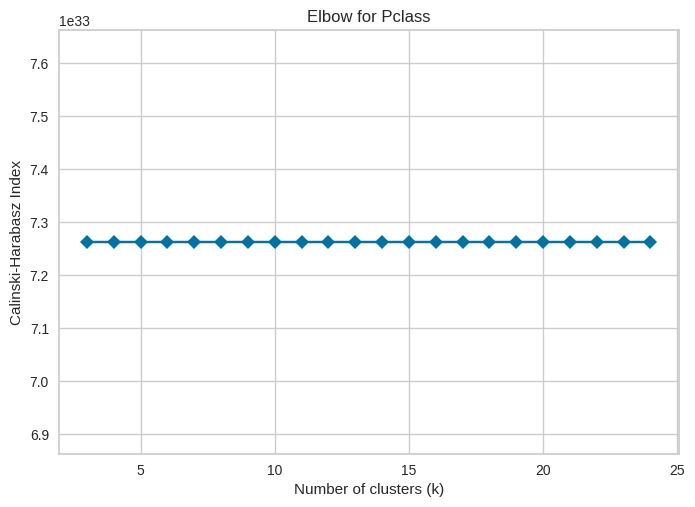


Processing numeric feature: Sex


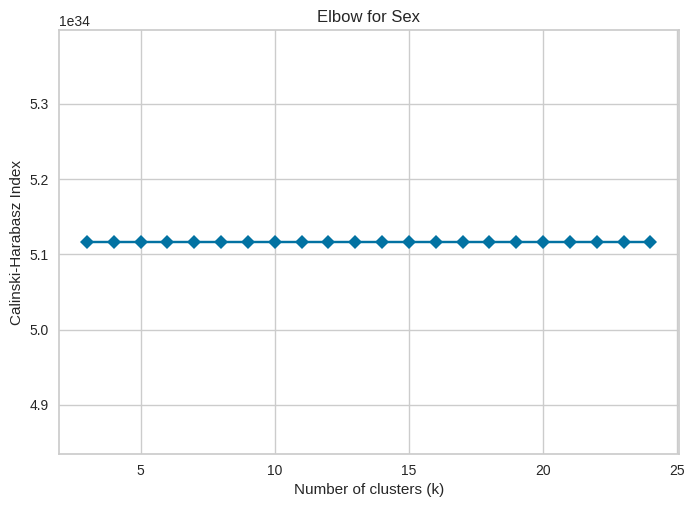


Processing numeric feature: Age


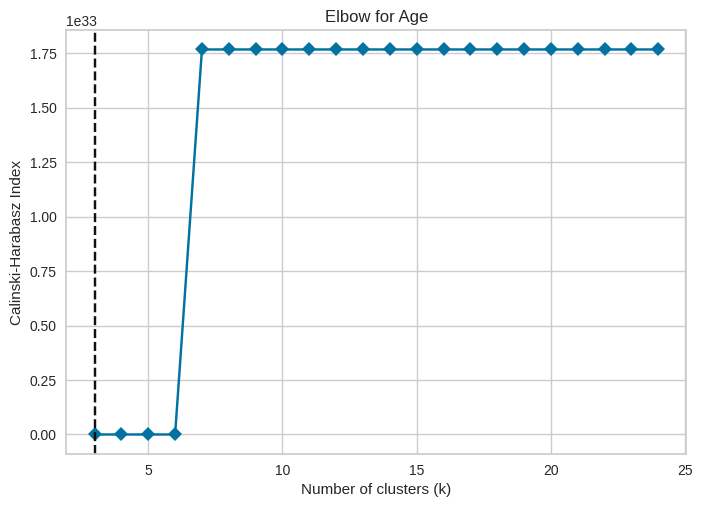


Processing numeric feature: SibSp


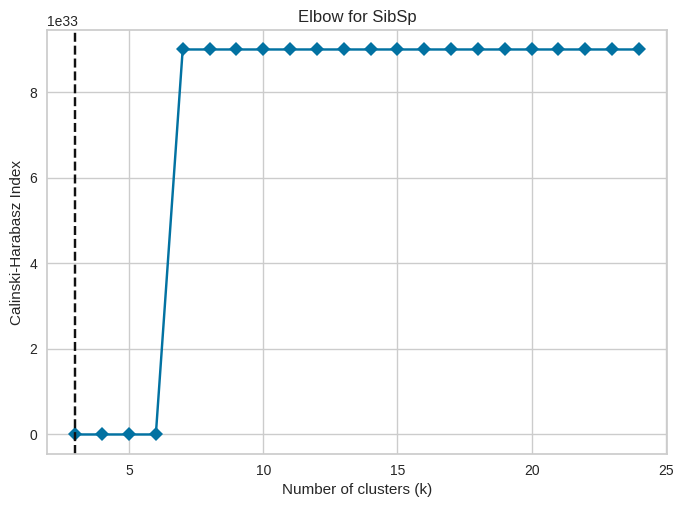


Processing numeric feature: Parch


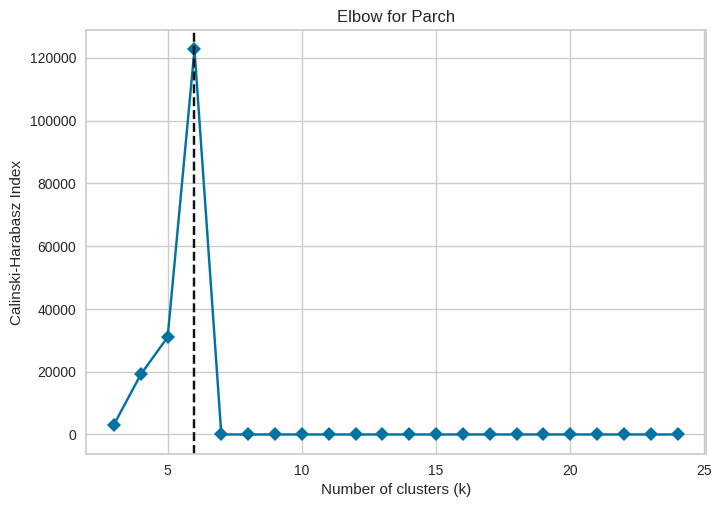


Processing numeric feature: Fare


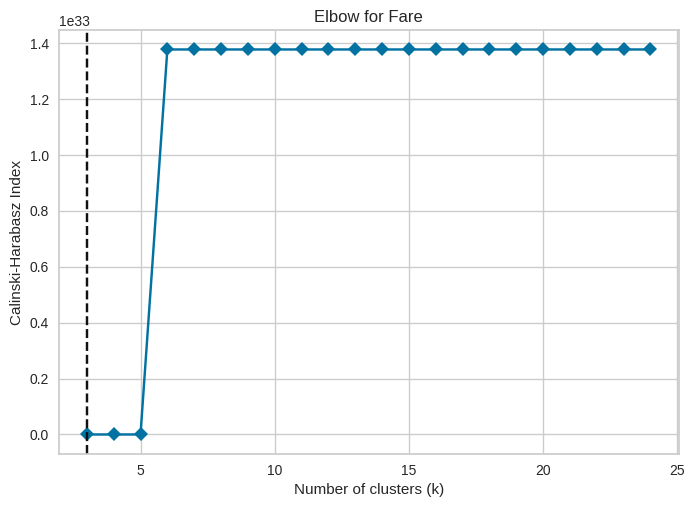


Processing numeric feature: Embarked


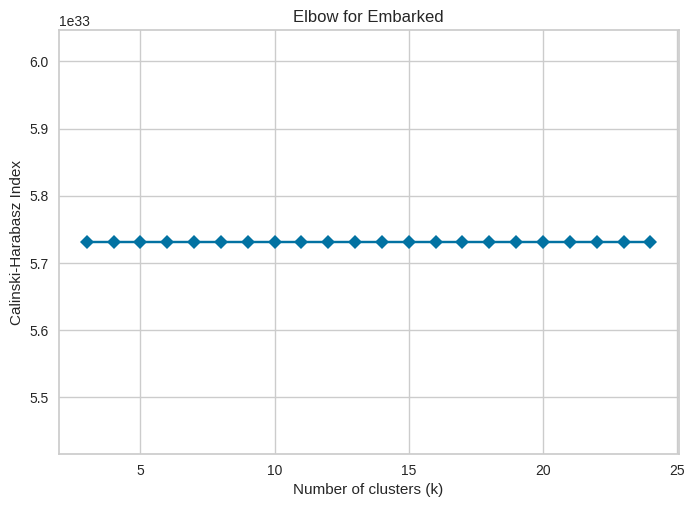


Processing numeric feature: relatives


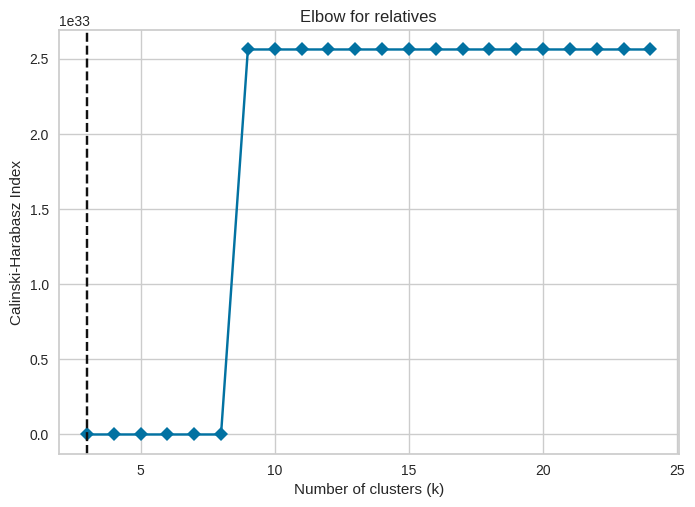


Processing numeric feature: not_alone


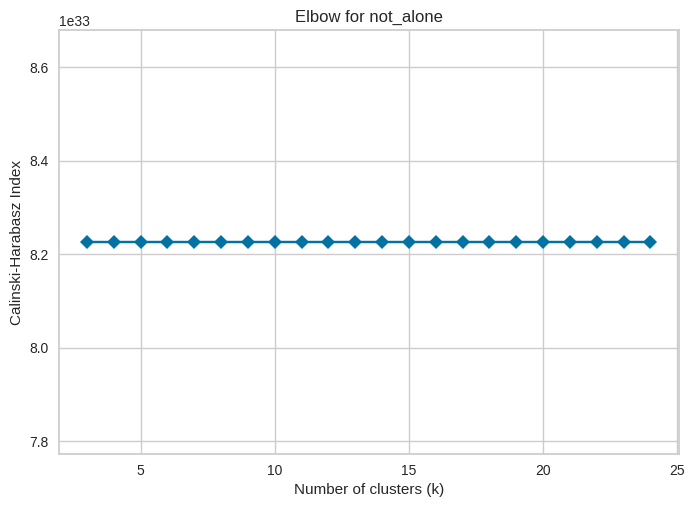


Processing numeric feature: Deck


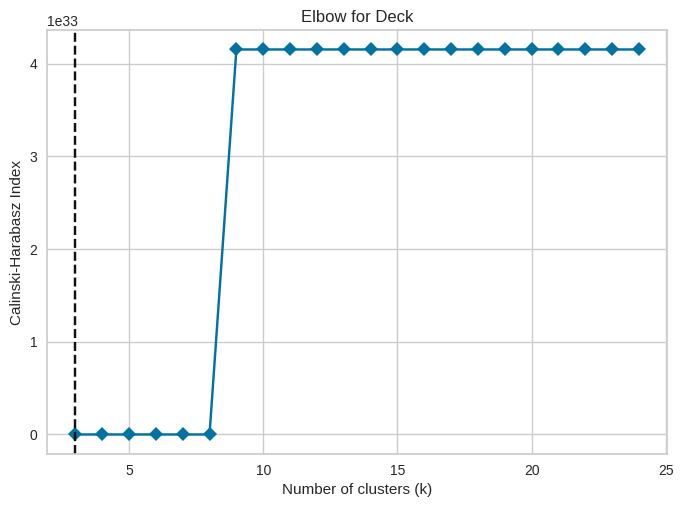


Processing numeric feature: Title


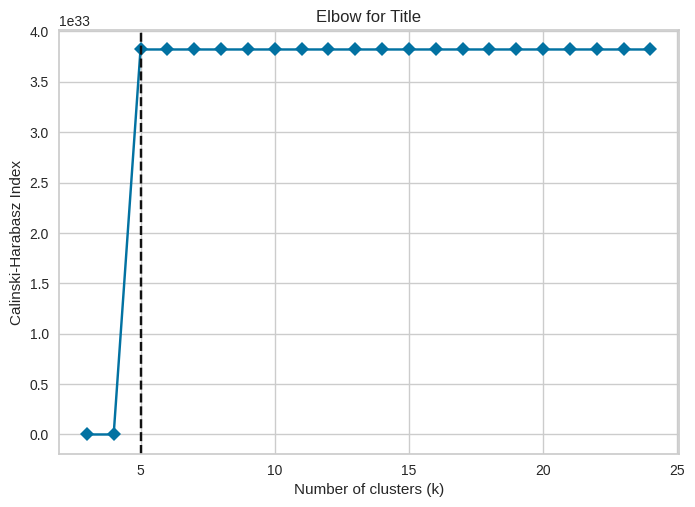


Processing numeric feature: Age_Class


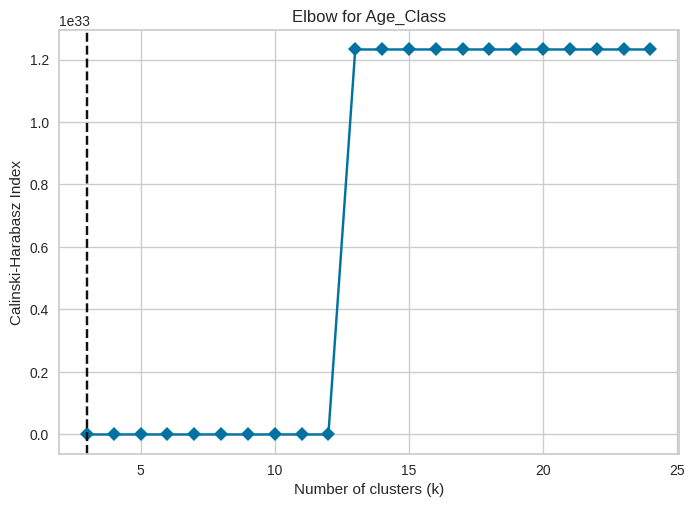


Processing numeric feature: Fare_Per_Person


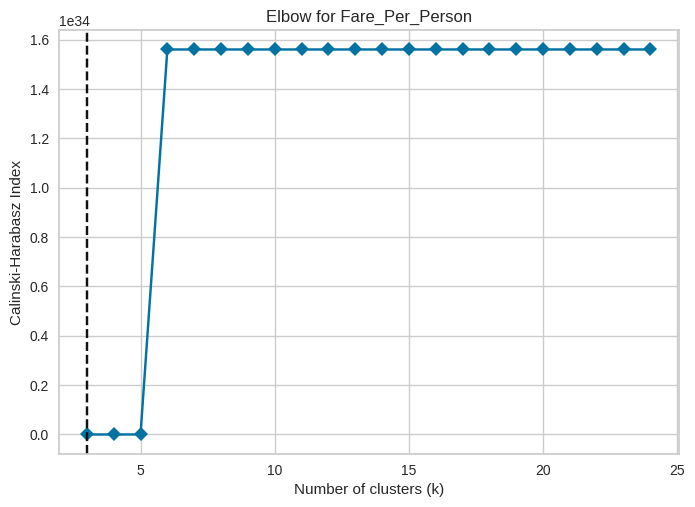

+-----------------------------+--------------------+
|     Cluster WOE Feature     |   Accuracy (CV)    |
+-----------------------------+--------------------+
|      Pclass_cluster_WOE     | 0.6857447743393384 |
|       Sex_cluster_WOE       | 0.7867553825874082 |
|       Age_cluster_WOE       | 0.6161634548992531 |
|      SibSp_cluster_WOE      | 0.6374678300169481 |
|      Parch_cluster_WOE      | 0.6363693427907852 |
|       Fare_cluster_WOE      | 0.6621869311405436 |
|     Embarked_cluster_WOE    | 0.6397275751679116 |
|    relatives_cluster_WOE    | 0.6486786767936727 |
|    not_alone_cluster_WOE    | 0.6273994099554328 |
|       Deck_cluster_WOE      | 0.6924612390935911 |
|      Title_cluster_WOE      | 0.7923733601154981 |
|    Age_Class_cluster_WOE    | 0.6195154102065155 |
| Fare_Per_Person_cluster_WOE | 0.6307450881928316 |
+-----------------------------+--------------------+


In [13]:
# unimportant_features = [
#     'Age_log', 'Cabin_level', 'Ticket_price_log', 
#     'Group_size_count', 'HomePlanet_count', 'Destination_count'
# ]

X_train_Clust_OHE, X_test_Clust_OHE = clustering_onehot_pipeline(X_train, X_test, y_train_int, num_cols)


In [140]:
# If you want a model using everything
X_train_Clust_OHE = X_train_Clust_OHE[[col for col in X_train_Clust_OHE.columns if '_cluster' in col or '_OHE_' in col]]
X_test_Clust_OHE = X_test_Clust_OHE[[col for col in X_test_Clust_OHE.columns if '_cluster' in col or '_OHE_' in col]]

X_train_all = pd.concat([X_train, X_train_Clust_OHE], axis=1)
X_test_all = pd.concat([X_test, X_test_Clust_OHE], axis=1)


# KNN-based target features (Very popular in Kaggle competitions)
Creating leakage-safe KNN-based target features that summarize how similar rows behave, then feeding them into another model.
Creating new features that describe:

1. How similar each sample is to its nearest neighbors

2. How neighbors’ labels behave around that sample

Often boost simple models (Logistic / LGBM / CatBoost) a LOT
This is feature engineering > model complexity philosophy.

In [14]:
import time
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# -----------------------------
# KNN meta-features (out-of-fold for train)
# -----------------------------
def knn_kfold_features(X, y, k=5, n_splits=5, random_state=42):
    """
    Generate KNN-based target probability features using K-Fold CV.
    Does NOT modify the original X or y.
    Returns a numpy array of shape (n_samples, n_classes)
    """
    X_copy = np.asarray(X)  # work on a copy
    y_copy = np.asarray(y)
    
    n_samples = X_copy.shape[0]
    n_classes = len(np.unique(y_copy))
    
    features = np.zeros((n_samples, n_classes))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    for train_idx, val_idx in skf.split(X_copy, y_copy):
        X_tr, X_val = X_copy[train_idx], X_copy[val_idx]
        y_tr = y_copy[train_idx]
        
        # Standardize per fold
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)
        
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
        knn.fit(X_tr_scaled, y_tr)
        features[val_idx] = knn.predict_proba(X_val_scaled)
    
    return features

# -----------------------------
# KNN meta-features for test set
# -----------------------------
def knn_test_features(X_train, y_train, X_test, k=5):
    """
    Generate KNN-based target probability features for test set.
    Does NOT modify X_train, y_train, or X_test.
    Returns a numpy array of shape (n_test_samples, n_classes)
    """
    X_train_copy = np.asarray(X_train)
    y_train_copy = np.asarray(y_train)
    X_test_copy = np.asarray(X_test)
    
    # Standardize based on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_copy)
    X_test_scaled = scaler.transform(X_test_copy)
    
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    knn.fit(X_train_scaled, y_train_copy)
    
    return knn.predict_proba(X_test_scaled)

# -----------------------------
# Example: generate KNN features
# -----------------------------
def generate_knn_features(X_train, X_test, y_train, K=5):
    # 1️⃣ Select numeric features only
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    X_train_num = X_train[num_cols]
    X_test_num  = X_test[num_cols]

    # 2️⃣ Generate train features (out-of-fold)
    start = time.time()
    X_tr_knn = knn_kfold_features(X_train_num, y_train, k=K, n_splits=5)
    print("Train KNN features time:", time.time() - start)

    # 3️⃣ Generate test features
    start = time.time()
    X_te_knn = knn_test_features(X_train_num, y_train, X_test_num, k=K)
    print("Test KNN features time:", time.time() - start)

    # 4️⃣ Create column names
    n_classes = len(np.unique(y_train))
    knn_cols = [f'KNN_class{c}' for c in range(n_classes)]

    # 5️⃣ Convert to DataFrames (preserve index)
    X_train_knn_df = pd.DataFrame(X_tr_knn, columns=knn_cols, index=X_train.index)
    X_test_knn_df  = pd.DataFrame(X_te_knn, columns=knn_cols, index=X_test.index)

    return X_train_knn_df, X_test_knn_df




In [15]:
# -----------------------------
# Usage
# -----------------------------
X_train_knn_df, X_test_knn_df = generate_knn_features(X_train, X_test, y_train_int, K=5)


Train KNN features time: 0.020073413848876953
Test KNN features time: 0.00406193733215332


In [ ]:

# Original X_train / X_test are untouched
# You can merge if you want:
X_train_all = pd.concat([X_train.copy(), X_train_knn_df], axis=1)
X_test_all  = pd.concat([X_test.copy(), X_test_knn_df], axis=1)




##  Multiplicative Features



In this section, a new product feature if created on by multiplying all continuous original features. The final selection of features depend on the Accuracy values with a cutoff


In [16]:
from itertools import combinations
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from prettytable import PrettyTable
import numpy as np
import pandas as pd

# -----------------------------
# Safe feature engineering: Pairwise products of numeric features
# -----------------------------
def generate_pairwise_features(X_train, X_test, y_train, num_cols, acc_threshold=0.7, n_splits=5):
    """
    Generate new features as pairwise products of numeric columns.
    Evaluate each new feature using CV with LogisticRegression.
    Categorize as 'selected' or 'unimportant' based on mean CV accuracy.

    Returns:
    - X_train_new, X_test_new: copies of datasets with pairwise features added
    - selected_features: list of selected pair names
    - unimportant_features: list of unimportant pair names
    """

    X_train_new = X_train.copy()
    X_test_new = X_test.copy()

    feature_pairs = list(combinations(num_cols, 2))
    selected_features = []
    unimportant_features = []

    table = PrettyTable()
    table.field_names = ['Pair Features', 'Accuracy(CV-TRAIN)', 'Selected']

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col1, col2 in feature_pairs:
        name = f'{col1}_{col2}_product'

        # 1️⃣ Create pairwise product feature
        X_train_feat = X_train_new[col1] * X_train_new[col2]
        X_test_feat = X_test_new[col1] * X_test_new[col2]

        # 2️⃣ Evaluate via CV
        X_feat = X_train_feat.values.reshape(-1, 1)
        y_array = y_train.values.ravel()  # ensure 1D array
        acc_list = []

        for train_idx, val_idx in kf.split(X_feat, y_array):
            X_tr, X_val = X_feat[train_idx], X_feat[val_idx]
            y_tr, y_val = y_array[train_idx], y_array[val_idx]

            # Impute missing values
            imputer = SimpleImputer(strategy='median')
            X_tr = imputer.fit_transform(X_tr)
            X_val = imputer.transform(X_val)

            # Fit Logistic Regression
            model = LogisticRegression()
            model.fit(X_tr, y_tr)
            y_pred = model.predict_proba(X_val)[:, 1]

            # Custom cutoff
            cutoff = acc_cutoff(y_val, y_pred)
            y_pred_bin = (y_pred > cutoff).astype(int)

            # Accuracy
            acc_list.append(accuracy_score(y_val, y_pred_bin))

        mean_acc = np.mean(acc_list)

        # 3️⃣ Decide selected/unimportant
        if mean_acc < acc_threshold:
            unimportant_features.append(name)
            selected = "No"
        else:
            selected_features.append(name)
            selected = "Yes"

        # 4️⃣ Add feature to datasets
        X_train_new[name] = X_train_feat
        X_test_new[name] = X_test_feat

        # 5️⃣ Add row to table
        table.add_row([f"{col1}*{col2}", mean_acc, selected])

    # Sort table by accuracy descending
    table.sortby = 'Accuracy(CV-TRAIN)'
    table.reversesort = True
    print(table)

    return X_train_new, X_test_new, selected_features, unimportant_features


In [17]:

X_train_mult, X_test_mult, selected_features, unimportant_features = generate_pairwise_features(
    X_train, X_test, y_train_int, num_cols, acc_threshold=0.7
)


+---------------------------+--------------------+----------+
|       Pair Features       | Accuracy(CV-TRAIN) | Selected |
+---------------------------+--------------------+----------+
|         Sex*Title         | 0.786761659657272  |   Yes    |
|          Sex*Deck         | 0.786761659657272  |   Yes    |
|         Pclass*Sex        | 0.786761659657272  |   Yes    |
|       Sex*Age_Class       | 0.7800326407632917 |   Yes    |
|          Sex*Age          | 0.7800326407632917 |   Yes    |
|          Sex*Fare         | 0.7676981984809491 |   Yes    |
|    Sex*Fare_Per_Person    | 0.7598204758018957 |   Yes    |
|         Fare*Title        | 0.7418806101311908 |   Yes    |
|         Deck*Title        | 0.7284162952733663 |   Yes    |
|   Title*Fare_Per_Person   | 0.7227669323959576 |   Yes    |
|         Age*Title         | 0.7161195154102065 |   Yes    |
|       Sex*relatives       | 0.7059506622308706 |   Yes    |
|        Sex*Embarked       | 0.6980917707614085 |    No    |
|       

In [ ]:
X_train_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')
X_test_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')


In [147]:
#remove unimportant features

X_train_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')
X_test_mult.drop(columns=unimportant_features, inplace=True, errors='ignore')

X_train_mult = X_train_mult[selected_features]
X_test_mult = X_test_mult[selected_features]

X_train_all = pd.concat([X_train, X_train_mult], axis=1)
X_test_all  = pd.concat([X_test, X_test_mult], axis=1)






# Rounding & quantile based binning
<mark>best to use on the top 10 features in feature importance of random forest</mark>

It does two main things for each selected numeric column:

Quantile binning (q-binning) – creates categorical features based on the distribution of the original column.

Rounding at different scales – creates “coarsened” versions of numeric features to capture broader trends.

In [18]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from prettytable import PrettyTable

# -----------------------------
# Safe feature engineering: Quantile-binning and rounding features
# -----------------------------
def generate_qbinned_rounded_features(X_train, X_test, columns=None, q=10):
    """
    Generate new features:
    - Quantile-binned features (LabelEncoded)
    - Rounded features: rounded, *10, *100

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features
    X_test : pd.DataFrame
        Test features
    columns : list or None
        Columns to process; if None, all numeric columns
    q : int
        Number of quantiles for qcut

    Returns
    -------
    X_train_new : pd.DataFrame
        ONLY the newly generated features for train
    X_test_new : pd.DataFrame
        ONLY the newly generated features for test
    encoders : dict
        Dictionary of LabelEncoders for quantile-binned features
    """

    X_train_new = pd.DataFrame(index=X_train.index)
    X_test_new = pd.DataFrame(index=X_test.index)
    encoders = {}

    # Default: use numeric columns only
    if columns is None:
        columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

    table = PrettyTable()
    table.field_names = ['Feature', 'Type', 'Status']

    for col in columns:
        # -------------------------
        # Quantile binning
        # -------------------------
        qbinned_col = f"{col}_qbinned"
        X_train_new[qbinned_col] = pd.qcut(
            X_train[col].values, q=q, labels=False, duplicates='drop'
        )
        le = LabelEncoder()
        X_train_new[qbinned_col] = le.fit_transform(X_train_new[qbinned_col])
        encoders[qbinned_col] = le
        table.add_row([qbinned_col, 'quantile_bin', 'train added'])

        # Apply same qcut to test using training bins
        X_test_new[qbinned_col] = pd.qcut(
            X_test[col].values, q=q, labels=False, duplicates='drop'
        )
        X_test_new[qbinned_col] = le.transform(X_test_new[qbinned_col])
        table.add_row([qbinned_col, 'quantile_bin', 'test added'])

        # -------------------------
        # Rounded features
        # -------------------------
        for scale in [1, 10, 100]:
            rounded_col = f"{col}_rounded" if scale == 1 else f"{col}_rounded_{scale}"
            X_train_new[rounded_col] = np.round(scale * X_train[col].values)
            X_test_new[rounded_col] = np.round(scale * X_test[col].values)
            table.add_row([rounded_col, f'round*{scale}', 'added'])

    print(table)
    return X_train_new, X_test_new, encoders


In [19]:
X_train_qb_and_roun, X_test_qb_and_roun, encoders = generate_qbinned_rounded_features(X_train, X_test)

+-----------------------------+--------------+-------------+
|           Feature           |     Type     |    Status   |
+-----------------------------+--------------+-------------+
|        Pclass_qbinned       | quantile_bin | train added |
|        Pclass_qbinned       | quantile_bin |  test added |
|        Pclass_rounded       |   round*1    |    added    |
|      Pclass_rounded_10      |   round*10   |    added    |
|      Pclass_rounded_100     |  round*100   |    added    |
|         Sex_qbinned         | quantile_bin | train added |
|         Sex_qbinned         | quantile_bin |  test added |
|         Sex_rounded         |   round*1    |    added    |
|        Sex_rounded_10       |   round*10   |    added    |
|       Sex_rounded_100       |  round*100   |    added    |
|         Age_qbinned         | quantile_bin | train added |
|         Age_qbinned         | quantile_bin |  test added |
|         Age_rounded         |   round*1    |    added    |
|        Age_rounded_10 

# Gaussian Mixture Clustering


<mark>The code transforms numeric features into cluster-based features (hard and soft) using a GMM, highlighting hidden structure in your data to help ML models make better predictions.</mark>


<mark>the overall data distribution doesn’t need to be normal.</mark>

For example, for each point, you can use:

Cluster probability features (soft assignments)

Hard cluster label (argmax of probabilities)

These features sometimes improve tree-based models or logistic regression, especially when the original numeric features alone don’t capture complex structure.

1️⃣ What is Gaussian Mixture Clustering
Gaussian Mixture Model (GMM) assumes the data comes from a mixture of several Gaussian distributions (clusters).

2️⃣ Why use GMM for Feature Engineering

1. Capture latent structure in data

- Sometimes numerical features don’t reveal the underlying patterns.

2. Generate new predictive features

- Hard cluster labels: Assign each point to the most likely cluster.
- Soft cluster probabilities: Use the probability of belonging to each cluster as a feature vector.
- These features often improve models like LightGBM, XGBoost, Logistic Regression by giving them insight into hidden patterns.

In [20]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold

def generate_gmm_features_fast(X_train, X_test, y_train=None,
                               n_components=5,
                               covariance_type='diag',
                               random_state=42,
                               use_cv=False, cv_splits=3,
                               sample_size=None):
    """
    Fast Gaussian Mixture feature generation.
    
    Features generated:
    - Hard cluster labels (categorical)
    - Soft cluster probabilities (per cluster)
    - Log-likelihood of each sample

    Parameters
    ----------
    X_train : pd.DataFrame
        Training features (numeric recommended)
    X_test : pd.DataFrame
        Test features
    y_train : pd.Series or None
        Optional target for CV-based selection
    n_components : int
        Number of Gaussian clusters
    covariance_type : str
        'full', 'tied', 'diag', 'spherical' (diag recommended for speed)
    random_state : int
    use_cv : bool
        If True, select n_components via CV (slow)
    cv_splits : int
        Number of folds if use_cv=True
    sample_size : int or None
        If using CV, max samples per fold for speed

    Returns
    -------
    X_train_gmm : pd.DataFrame
    X_test_gmm : pd.DataFrame
    gmm_model : GaussianMixture
    """

    # 1️⃣ Scale features
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 2️⃣ Optional CV to select best n_components
    if use_cv and y_train is not None:
        components_range = [n_components]  # minimal for speed
        # You can extend components_range=[2,3,4,5,...] if needed
        best_score = -np.inf
        best_n = n_components
        best_seed = random_state

        for comp in components_range:
            seeds = np.random.RandomState(random_state).randint(0, 100, size=cv_splits)
            kf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
            scores = []

            for i, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
                if sample_size:
                    # subsample to speed up
                    train_idx = np.random.choice(train_idx, size=min(len(train_idx), sample_size), replace=False)
                    val_idx   = np.random.choice(val_idx, size=min(len(val_idx), sample_size), replace=False)

                gm = GaussianMixture(n_components=comp, covariance_type=covariance_type,
                                     random_state=seeds[i])
                gm.fit(X_train_scaled[train_idx])
                scores.append(gm.score(X_train_scaled[val_idx]))

            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_n = comp

        print(f"Selected best n_components={best_n} with CV log-likelihood={best_score:.3f}")
        n_components = best_n

    # 3️⃣ Fit GMM on full training data
    gmm = GaussianMixture(n_components=n_components,
                          covariance_type=covariance_type,
                          random_state=random_state)
    gmm.fit(X_train_scaled)

    # 4️⃣ Generate features
    X_train_hard = gmm.predict(X_train_scaled)
    X_test_hard = gmm.predict(X_test_scaled)

    X_train_soft = gmm.predict_proba(X_train_scaled)
    X_test_soft = gmm.predict_proba(X_test_scaled)

    X_train_logL = gmm.score_samples(X_train_scaled)
    X_test_logL = gmm.score_samples(X_test_scaled)

    # 5️⃣ Combine into DataFrames
    gmm_cols = [f'GMM_prob_{i}' for i in range(n_components)]
    X_train_gmm = pd.DataFrame(X_train_soft, columns=gmm_cols, index=X_train.index)
    X_test_gmm = pd.DataFrame(X_test_soft, columns=gmm_cols, index=X_test.index)

    X_train_gmm['GMM_label'] = X_train_hard
    X_train_gmm['GMM_logL'] = X_train_logL

    X_test_gmm['GMM_label'] = X_test_hard
    X_test_gmm['GMM_logL'] = X_test_logL

    return X_train_gmm, X_test_gmm, gmm


In [21]:

X_train_gmm, X_test_gmm, gmm_model = generate_gmm_features_fast(
    X_train=X_train[num_cols],
    X_test=X_test[num_cols],
    n_components=5,           # pick a reasonable number of clusters
    covariance_type='diag',    # fast for high-dimensional
    random_state=42,
    use_cv=False               # skip CV for speed
)




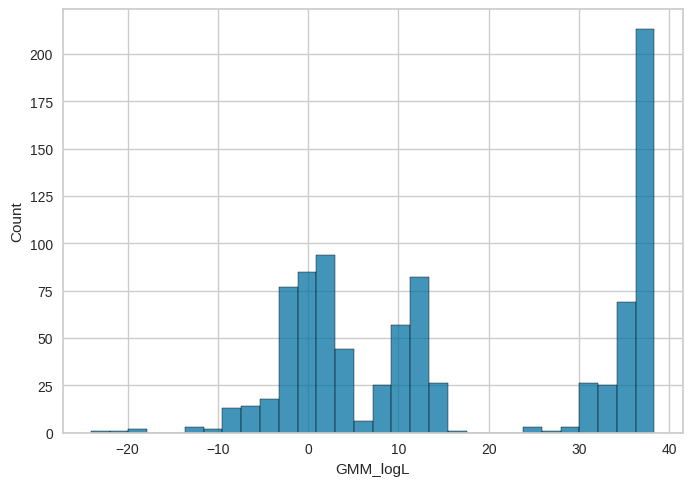

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of hard cluster labels
# sns.countplot(X_train_gmm['GMM_cluster_label'])
# plt.show()

# Distribution of log-likelihoods
sns.histplot(X_train_gmm['GMM_logL'], bins=30)
plt.show()


# row-wise statistical features
This is row-wise feature engineering, often useful when you have many numeric features and want the model to capture overall patterns.

In [3]:
import pandas as pd

def generate_row_stats_features(X_train, X_test, columns=None):
    """
    Generate row-wise statistical features:
    sum, min, max, mean, std, skew, kurtosis, median
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training data
    X_test : pd.DataFrame
        Test data
    columns : list or None
        Columns to use for aggregation; if None, use all columns in X_train
    
    Returns
    -------
    X_train_stats : pd.DataFrame
        Row-wise statistics features for train
    X_test_stats : pd.DataFrame
        Row-wise statistics features for test
    """
    if columns is None:
        columns = X_train.columns.tolist()
    
    X_train_stats = pd.DataFrame(index=X_train.index)
    X_test_stats  = pd.DataFrame(index=X_test.index)
    
    # Define row-wise stats
    stats = {
        'sum': pd.DataFrame.sum,
        'min': pd.DataFrame.min,
        'max': pd.DataFrame.max,
        'mean': pd.DataFrame.mean,
        'std': pd.DataFrame.std,
        'skew': pd.DataFrame.skew,
        'kurt': pd.DataFrame.kurt,
        'med': pd.DataFrame.median
    }
    
    for stat_name, func in stats.items():
        X_train_stats[stat_name] = func(X_train[columns], axis=1)
        X_test_stats[stat_name]  = func(X_test[columns], axis=1)
    
    return X_train_stats, X_test_stats


In [4]:
X_train_stats, X_test_stats = generate_row_stats_features(X_train, X_test, columns=num_cols)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_feature_distribution(X, y, features):
    """
    Plots the distribution of features for two classes in y.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature DataFrame
    y : pd.Series or array-like
        Target values (binary)
    features : list of str
        Feature columns to plot
    """
    # Ensure y is a Series aligned with X
    if not isinstance(y, pd.Series):
        y = pd.Series(y, index=X.index)
    
    sns.set_style('whitegrid')
    num_features = len(features)
    ncols = 5  # number of subplots per row
    nrows = int(np.ceil(num_features / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*3))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        t0 = X.loc[y == 0, feature]
        t1 = X.loc[y == 1, feature]
        
        sns.kdeplot(t0, ax=axes[i], label='target: 0', fill=True, alpha=0.5)
        sns.kdeplot(t1, ax=axes[i], label='target: 1', fill=True, alpha=0.5)
        axes[i].set_title(feature, fontsize=10)
        axes[i].tick_params(axis='x', labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()


features = X_train_stats.columns  # your new row-wise stats features
plot_feature_distribution(X_train_stats, y_train['target'], features)


ValueError: Data must be 1-dimensional, got ndarray of shape (891, 1) instead

# interaction features (+-*/)

<mark>It might take time</mark>

This function automatically generates interaction features between numerical columns in a dataset, including **addition, subtraction, multiplication, and division**. Each candidate feature is evaluated using cross-validated ROC AUC with a simple gradient boosting model, and only those features that improve predictive performance and are not highly correlated with existing numeric features are kept.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

def generate_interaction_features(train, test, y_train, cols, best_score=0.5, cv_splits=5):
    """
    Generate interaction features (add, subtract, multiply, divide) between numerical columns
    and keep only those that improve CV ROC AUC and are not too correlated with existing features.

    Only numeric columns are used for correlation checks.

    Parameters
    ----------
    train : pd.DataFrame
        Training data (without target).
    test : pd.DataFrame
        Test data.
    y_train : pd.Series
        Target variable.
    cols : list
        List of numerical columns to consider for interactions.
    best_score : float
        Minimum ROC AUC required to keep a new feature.
    cv_splits : int
        Number of CV folds for evaluation.

    Returns
    -------
    train_new : pd.DataFrame
        Training set with new features added.
    test_new : pd.DataFrame
        Test set with new features added.
    new_cols : list
        List of new column names added.
    """

    train_new = train.copy()
    test_new = test.copy()
    new_cols = []

    skf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    
    for i in tqdm(range(len(cols)), desc="Generating Interaction Features"):
        col1 = cols[i]

        for j in range(i+1, len(cols)):
            col2 = cols[j]
            operations = {
                f"{col1}*{col2}": train[col1] * train[col2],
                f"{col1}/{col2}": train[col1] / (train[col2] + 1e-5),
                f"{col2}/{col1}": train[col2] / (train[col1] + 1e-5),
                f"{col1}-{col2}": train[col1] - train[col2],
                f"{col1}+{col2}": train[col1] + train[col2]
            }

            for name, series in operations.items():
                # Skip constant features
                if series.nunique() <= 1:
                    continue

                # CV evaluation
                X_feature = series.values.reshape(-1,1)
                y_target = y_train.values
                auc_scores = []
                for train_idx, val_idx in skf.split(X_feature, y_target):
                    X_tr, X_val = X_feature[train_idx], X_feature[val_idx]
                    y_tr, y_val = y_target[train_idx], y_target[val_idx]
                    model = HistGradientBoostingClassifier(
                        max_iter=300, learning_rate=0.02, max_depth=6, random_state=42
                    )
                    model.fit(X_tr, y_tr)
                    preds = model.predict_proba(X_val)[:,1]
                    auc_scores.append(roc_auc_score(y_val, preds))
                mean_auc = np.mean(auc_scores)

                # Only check correlation against numeric columns
                numeric_cols = train_new.select_dtypes(include=np.number).columns.tolist()
                if numeric_cols:
                    corr_with_existing = train_new[numeric_cols].corrwith(series)
                    max_corr = corr_with_existing.abs().max()
                else:
                    max_corr = 0

                if mean_auc > best_score and max_corr < 0.9:
                    # Add feature to train/test
                    train_new[name] = series
                    if "*" in name:
                        test_new[name] = test[col1] * test[col2]
                    elif "/" in name:
                        test_new[name] = test[col1] / (test[col2] + 1e-5) if name.startswith(col1) else test[col2] / (test[col1] + 1e-5)
                    elif "+" in name:
                        test_new[name] = test[col1] + test[col2]
                    elif "-" in name:
                        test_new[name] = test[col1] - test[col2] if name.startswith(col1) else test[col2] - test[col1]
                    
                    new_cols.append(name)
                    print(f"Added '{name}' | CV ROC AUC: {mean_auc:.4f} | Max Corr: {max_corr:.4f}")

    return train_new, test_new, new_cols

In [4]:
selected_cols = num_cols


# Use the function
train_interaction, test_interaction, interaction_cols = generate_interaction_features(
    train=X_train,
    test=X_test,
    y_train=y_train,
    cols=selected_cols,
    best_score=0.55,   # only keep features improving ROC AUC over 0.55
    cv_splits=3
)

Generating Interaction Features:   0%|          | 0/14 [00:00<?, ?it/s]

Added 'CreditScore*Age' | CV ROC AUC: 0.7109 | Max Corr: 0.8789
Added 'CreditScore/Age' | CV ROC AUC: 0.7262 | Max Corr: 0.8249


Generating Interaction Features:   7%|▋         | 1/14 [04:30<58:33, 270.28s/it]

Added 'Age/Tenure' | CV ROC AUC: 0.6995 | Max Corr: 0.3078
Added 'Age*NumOfProducts' | CV ROC AUC: 0.7936 | Max Corr: 0.8140
Added 'Age/NumOfProducts' | CV ROC AUC: 0.8426 | Max Corr: 0.8097
Added 'Age*EstimatedSalary' | CV ROC AUC: 0.6186 | Max Corr: 0.8698
Added 'Age/EstimatedSalary' | CV ROC AUC: 0.5990 | Max Corr: 0.0718
Added 'EstimatedSalary/Age' | CV ROC AUC: 0.5988 | Max Corr: 0.8776
Added 'Age/Surname_tfidf_0' | CV ROC AUC: 0.6986 | Max Corr: 0.1614
Added 'Age/Surname_tfidf_1' | CV ROC AUC: 0.6736 | Max Corr: 0.1281
Added 'Age/Surname_tfidf_2' | CV ROC AUC: 0.6777 | Max Corr: 0.1394
Added 'Age/Sur_Geo_Gend_Sal_tfidf_0' | CV ROC AUC: 0.7596 | Max Corr: 0.0226
Added 'Age/Sur_Geo_Gend_Sal_tfidf_1' | CV ROC AUC: 0.7604 | Max Corr: 0.0813
Added 'Age/Sur_Geo_Gend_Sal_tfidf_2' | CV ROC AUC: 0.7600 | Max Corr: 0.3409


Generating Interaction Features:  14%|█▍        | 2/14 [09:38<58:27, 292.31s/it]

...

Generating Interaction Features:  64%|██████▍   | 9/14 [28:21<11:51, 142.32s/it]

Added 'Surname_tfidf_1*Surname_tfidf_2' | CV ROC AUC: 0.5702 | Max Corr: 0.8789
Added 'Surname_tfidf_2/Surname_tfidf_1' | CV ROC AUC: 0.5684 | Max Corr: 0.6106
Added 'Surname_tfidf_1-Surname_tfidf_2' | CV ROC AUC: 0.5717 | Max Corr: 0.7041
Added 'Surname_tfidf_1+Surname_tfidf_2' | CV ROC AUC: 0.5734 | Max Corr: 0.7105


Generating Interaction Features:  71%|███████▏  | 10/14 [30:10<08:48, 132.04s/it]

Added 'Surname_tfidf_2/Sur_Geo_Gend_Sal_tfidf_0' | CV ROC AUC: 0.5697 | Max Corr: 0.8274
Added 'Surname_tfidf_2/Sur_Geo_Gend_Sal_tfidf_1' | CV ROC AUC: 0.5705 | Max Corr: 0.8525


Generating Interaction Features: 100%|██████████| 14/14 [31:56<00:00, 136.92s/it]


##### Automatic Interaction Feature Search

Instead of blindly creating thousands of features, we:
1️⃣ Generate candidate interactions
2️⃣ Test them with fast CV
3️⃣ Keep only features that improve AUC


In [20]:
from itertools import combinations
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier


def discover_interactions(train, test, y, num_cols, threshold=0.001):

    new_train = pd.DataFrame(index=train.index)
    new_test = pd.DataFrame(index=test.index)

    new_features = []

    model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Use only numeric columns for base model
    base_X = train[num_cols]

    base_scores = []

    for tr, val in skf.split(base_X, y):

        model.fit(base_X.iloc[tr], y.iloc[tr])
        preds = model.predict_proba(base_X.iloc[val])[:,1]

        base_scores.append(roc_auc_score(y.iloc[val], preds))

    base_auc = np.mean(base_scores)

    print("Base AUC:", base_auc)

    for col1, col2 in combinations(num_cols, 2):

        feature_name = f"{col1}_x_{col2}"

        feature = train[col1] * train[col2]

        X_tmp = pd.concat([base_X, feature], axis=1)

        scores = []

        for tr, val in skf.split(X_tmp, y):

            model.fit(X_tmp.iloc[tr], y.iloc[tr])
            preds = model.predict_proba(X_tmp.iloc[val])[:,1]

            scores.append(roc_auc_score(y.iloc[val], preds))

        new_auc = np.mean(scores)

        if new_auc > base_auc + threshold:

            print(feature_name, "improved:", new_auc)

            new_train[feature_name] = train[col1] * train[col2]
            new_test[feature_name] = test[col1] * test[col2]

            new_features.append(feature_name)

            base_auc = new_auc

    return new_train, new_test, new_features

In [21]:
train_new, test_new, new_feats = discover_interactions(
    train=X_train,
    test=X_test,
    y=y_train,
    num_cols=num_cols
)

[LightGBM] [Info] Number of positive: 23280, number of negative: 86742
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2353
[LightGBM] [Info] Number of data points in the train set: 110022, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.211594 -> initscore=-1.315344
[LightGBM] [Info] Start training from score -1.315344
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

#  interaction features between categorical 
It converts pairs of categorical features into a single encoded interaction feature.


- Combining two features into one

- Turning that combination into a numeric feature

- Doing it consistently for train and test


<mark>To Improve</mark>
“Target encoding smooths category averages with the global mean; min_samples_leaf is the pivot point where we trust the category mean more than the global mean.”

In [28]:
from sklearn.preprocessing import LabelEncoder
import time
import pandas as pd

def generate_cross_features(
    X_train,
    X_test,
    combs,
    verbose=True
):
    """
    Generate crossed categorical features (f1 + f2) using LabelEncoding.
    Does NOT modify X_train or X_test.
    Returns ONLY the newly generated feature columns.

    Parameters
    ----------
    X_train : pd.DataFrame
    X_test : pd.DataFrame
    combs : list of tuples
        List of (f1, f2) feature combinations
    verbose : bool

    Returns
    -------
    X_train_cross : pd.DataFrame
        New crossed features for training set
    X_test_cross : pd.DataFrame
        New crossed features for test set
    cross_features : list
        Names of generated features
    """

    X_train_cross = pd.DataFrame(index=X_train.index)
    X_test_cross  = pd.DataFrame(index=X_test.index)
    cross_features = []

    start = time.time()

    for n_c, (f1, f2) in enumerate(combs):
        name = f"{f1}_plus_{f2}"

        if verbose:
            print(
                'current feature %60s %4d in %5.1f'
                % (name, n_c + 1, (time.time() - start) / 60),
                end=''
            )
            print('\r' * 75, end='')

        # Combine as string
        trn_vals = X_train[f1].astype(str) + "_" + X_train[f2].astype(str)
        tst_vals = X_test[f1].astype(str)  + "_" + X_test[f2].astype(str)

        # Label encode jointly
        lbl = LabelEncoder()
        lbl.fit(pd.concat([trn_vals, tst_vals], axis=0))

        X_train_cross[name] = lbl.transform(trn_vals)
        X_test_cross[name]  = lbl.transform(tst_vals)

        cross_features.append(name)

    return X_train_cross, X_test_cross, cross_features


In [29]:

combs = [
    ('ps_reg_01', 'ps_car_02_cat'),  
    ('ps_reg_01', 'ps_car_04_cat'),
]
X_train_cross, X_test_cross, cross_feats = generate_cross_features(
    X_train=X_train,
    X_test=X_test,
    combs=combs
)


current feature                                 ps_reg_01_plus_ps_car_02_cat    1 in   0.0

KeyError: 'ps_reg_01'

# Frequency Encoding
<mark>Not sure if this code is good</mark>

In [19]:
import pandas as pd
import numpy as np
import time

def freq_encoding(cols, train_df, test_df, verbose=True):
    """
    Perform frequency encoding for a list of categorical columns.

    Parameters
    ----------
    cols : list
        List of categorical columns to frequency encode
    train_df : pd.DataFrame
        Training dataset
    test_df : pd.DataFrame
        Test dataset
    verbose : bool
        Whether to print progress

    Returns
    -------
    train_freq : pd.DataFrame
        DataFrame containing frequency-encoded features for training set
    test_freq : pd.DataFrame
        DataFrame containing frequency-encoded features for test set
    freq_features : list
        List of frequency-encoded feature names
    """

    train_freq = pd.DataFrame(index=train_df.index)
    test_freq  = pd.DataFrame(index=test_df.index)
    freq_features = []

    start = time.time()

    for i, col in enumerate(cols):
        col_freq = col + "_freq"

        if verbose:
            print(
                "Encoding column %60s %4d of %d in %5.2f min"
                % (col, i+1, len(cols), (time.time() - start)/60)
            )

        # Compute frequency counts in the training set
        freq = train_df[col].value_counts().to_dict()

        # Map frequencies to train and test sets
        train_freq[col_freq] = train_df[col].map(freq).fillna(0).astype(np.int32)
        test_freq[col_freq]  = test_df[col].map(freq).fillna(0).astype(np.int32)

        freq_features.append(col_freq)

    return train_freq, test_freq, freq_features


In [20]:
cols_to_encode = ['ps_ind_02_cat','ps_car_04_cat', 'ps_car_09_cat',
          'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_11_cat']
train_freq, test_freq, freq_features = freq_encoding(cols_to_encode, X_train, X_test)


Encoding column                                                ps_ind_02_cat    1 of 6 in  0.00 min
Encoding column                                                ps_car_04_cat    2 of 6 in  0.00 min
Encoding column                                                ps_car_09_cat    3 of 6 in  0.00 min
Encoding column                                                ps_ind_05_cat    4 of 6 in  0.00 min
Encoding column                                                ps_car_01_cat    5 of 6 in  0.00 min
Encoding column                                                ps_car_11_cat    6 of 6 in  0.00 min


# Binary Encoding

It takes a numeric categorical feature (values 0 to n‑1) and converts it into binary representation, creating multiple new columns—one for each binary digit (bit). This allows models to capture categorical information in a numeric, bitwise way.

Binary encoding is best used for categorical features with moderate-to-high cardinality, where one-hot encoding would create too many columns and slow down your model or make it sparse.

Example: user_id with 10,000 unique values.

<mark>“High-cardinality categorical → binary encoding saves columns, keeps info numeric, and works well with trees or linear models.”</mark>

In [22]:
import pandas as pd
import numpy as np

def binary_encoding(cols, train_df, test_df, verbose=True):
    """
    Perform binary encoding for numeric categorical features.
    Does NOT modify the original dataframes.
    Returns only the newly generated binary columns.

    Parameters
    ----------
    cols : list
        List of numeric categorical columns (0 to n-1)
    train_df : pd.DataFrame
        Training dataset
    test_df : pd.DataFrame
        Test dataset
    verbose : bool
        Print progress if True

    Returns
    -------
    train_bin : pd.DataFrame
        Binary encoded features for training set
    test_bin : pd.DataFrame
        Binary encoded features for test set
    bin_features : list
        Names of generated binary columns
    """

    train_bin = pd.DataFrame(index=train_df.index)
    test_bin  = pd.DataFrame(index=test_df.index)
    bin_features = []

    for i, feat in enumerate(cols):
        if verbose:
            print(f"Binary encoding column {i+1}/{len(cols)}: {feat}")

        # Handle missing values: map -1 to max + 1
        feat_max = max(train_df[feat].max(), test_df[feat].max())
        trn_vals = train_df[feat].replace(-1, feat_max + 1)
        tst_vals = test_df[feat].replace(-1, feat_max + 1)

        # All unique levels in train + test
        union_val = np.union1d(trn_vals.unique(), tst_vals.unique())
        max_bin_len = len("{0:b}".format(union_val.max()))

        # Create mapping: level -> binary digits
        bin_map = {val: [int(b) for b in format(val, f'0{max_bin_len}b')] for val in union_val}
        bin_cols = [feat + f"_bin_{j}" for j in range(max_bin_len)]

        # Map binary digits to train and test
        train_bin_feat = pd.DataFrame([bin_map[v] for v in trn_vals], columns=bin_cols, index=train_df.index)
        test_bin_feat  = pd.DataFrame([bin_map[v] for v in tst_vals], columns=bin_cols, index=test_df.index)

        # Add to final datasets
        train_bin = pd.concat([train_bin, train_bin_feat], axis=1)
        test_bin  = pd.concat([test_bin, test_bin_feat], axis=1)
        bin_features.extend(bin_cols)

    return train_bin, test_bin, bin_features


In [25]:
cols_to_binary = ['ps_ind_02_cat','ps_car_04_cat', 'ps_car_09_cat',
          'ps_ind_05_cat', 'ps_car_01_cat']
train_bin, test_bin, bin_features = binary_encoding(cols_to_binary, X_train, X_test)

train_bin.head()


Binary encoding column 1/5: ps_ind_02_cat
Binary encoding column 2/5: ps_car_04_cat
Binary encoding column 3/5: ps_car_09_cat
Binary encoding column 4/5: ps_ind_05_cat
Binary encoding column 5/5: ps_car_01_cat


,ps_ind_02_cat_bin_0,ps_ind_02_cat_bin_1,ps_ind_02_cat_bin_2,ps_car_04_cat_bin_0,ps_car_04_cat_bin_1,ps_car_04_cat_bin_2,ps_car_04_cat_bin_3,ps_car_09_cat_bin_0,ps_car_09_cat_bin_1,ps_car_09_cat_bin_2,ps_ind_05_cat_bin_0,ps_ind_05_cat_bin_1,ps_ind_05_cat_bin_2,ps_car_01_cat_bin_0,ps_car_01_cat_bin_1,ps_car_01_cat_bin_2,ps_car_01_cat_bin_3
0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
2,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,1,1
4,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,1,1



Encoding Functions

Below are 5 encoding functions. (1) encode_FE does frequency encoding where it combines train and test first and then encodes. (2) encode_LE is a label encoded for categorical features (3) encode_AG makes aggregated features such as aggregated mean and std (4) encode_CB combines two columns (5) encode_AG2 makes aggregated features where it counts how many unique values of one feature is within a group. For more explanation about feature engineering, see the discussion here


In [ ]:
# # FREQUENCY ENCODE TOGETHER
# def encode_FE(df1, df2, cols):
#     for col in cols:
#         df = pd.concat([df1[col],df2[col]])
#         vc = df.value_counts(dropna=True, normalize=True).to_dict()
#         vc[-1] = -1
#         nm = col+'_FE'
#         df1[nm] = df1[col].map(vc)
#         df1[nm] = df1[nm].astype('float32')
#         df2[nm] = df2[col].map(vc)
#         df2[nm] = df2[nm].astype('float32')
#         print(nm,', ',end='')
        
# # LABEL ENCODE
# def encode_LE(col,train=X_train,test=X_test,verbose=True):
#     df_comb = pd.concat([train[col],test[col]],axis=0)
#     df_comb,_ = df_comb.factorize(sort=True)
#     nm = col
#     if df_comb.max()>32000: 
#         train[nm] = df_comb[:len(train)].astype('int32')
#         test[nm] = df_comb[len(train):].astype('int32')
#     else:
#         train[nm] = df_comb[:len(train)].astype('int16')
#         test[nm] = df_comb[len(train):].astype('int16')
#     del df_comb; x=gc.collect()
#     if verbose: print(nm,', ',end='')
        
# # GROUP AGGREGATION MEAN AND STD
# # https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
# def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test, 
#               fillna=True, usena=False):
#     # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
#     for main_column in main_columns:  
#         for col in uids:
#             for agg_type in aggregations:
#                 new_col_name = main_column+'_'+col+'_'+agg_type
#                 temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
#                 if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
#                 temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
#                                                         columns={agg_type: new_col_name})

#                 temp_df.index = list(temp_df[col])
#                 temp_df = temp_df[new_col_name].to_dict()   

#                 train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
#                 test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
#                 if fillna:
#                     train_df[new_col_name].fillna(-1,inplace=True)
#                     test_df[new_col_name].fillna(-1,inplace=True)
                
#                 print("'"+new_col_name+"'",', ',end='')
                
# # COMBINE FEATURES
# def encode_CB(col1,col2,df1=X_train,df2=X_test):
#     nm = col1+'_'+col2
#     df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
#     df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
#     encode_LE(nm,verbose=False)
#     print(nm,', ',end='')
    
# # GROUP AGGREGATION NUNIQUE
# def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
#     for main_column in main_columns:  
#         for col in uids:
#             comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
#             mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
#             train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
#             test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
#             print(col+'_'+main_column+'_ct, ',end='')

**Target Encoding**

Smoothing is computed like in the following paper by Daniele Micci-Barreca
https://kaggle2.blob.core.windows.net/forum-message-attachments/225952/7441/high%20cardinality%20categoricals.pdf
trn_series : training categorical feature as a pd.Series
tst_series : test categorical feature as a pd.Series
target : target data as a pd.Series
min_samples_leaf (int) : minimum samples to take category average into account
smoothing (int) : smoothing effect to balance categorical average vs prior

In [35]:
import pandas as pd
import numpy as np

def add_noise(series, noise_level=0):
    """Add Gaussian noise to a pandas Series"""
    if noise_level > 0:
        return series * (1 + noise_level * np.random.randn(len(series)))
    return series

def target_encode_cols_simple(cols, X_train, X_test, y_train, min_samples_leaf=1, smoothing=1, noise_level=0, verbose=True):
    """
    Target encode multiple categorical columns using only train + test.

    Parameters
    ----------
    cols : list
        List of categorical columns to encode.
    X_train : pd.DataFrame
        Training dataset.
    X_test : pd.DataFrame
        Test dataset.
    y_train : pd.Series
        Target variable for training set.
    min_samples_leaf : int
        Minimum samples to take category average into account.
    smoothing : float
        Smoothing effect to balance categorical average vs prior.
    noise_level : float
        Optional Gaussian noise added to encoded values.
    verbose : bool
        Print progress if True.

    Returns
    -------
    train_enc : pd.DataFrame
        Target encoded features for training set.
    test_enc : pd.DataFrame
        Target encoded features for test set.
    enc_features : list
        Names of generated target encoded columns.
    """

    y_train = y_train.squeeze()

    train_enc = pd.DataFrame(index=X_train.index)
    test_enc  = pd.DataFrame(index=X_test.index)
    enc_features = []

    prior = y_train.mean()  # global mean

    for i, col in enumerate(cols):
        if verbose:
            print(f"Target encoding column {i+1}/{len(cols)}: {col}")

        # Compute target averages
        temp = pd.concat([X_train[col], y_train], axis=1)
        averages = temp.groupby(col)[y_train.name].agg(["mean", "count"])

        # Smoothing
        smooth = 1 / (1 + np.exp(-(averages["count"] - min_samples_leaf) / smoothing))
        averages[y_train.name] = prior * (1 - smooth) + averages["mean"] * smooth
        averages.drop(["mean", "count"], axis=1, inplace=True)
        averages = averages.reset_index()

        # Merge averages to train and test
        def merge_avg(df):
            merged = pd.merge(
                df[[col]],
                averages.rename(columns={col: col, y_train.name: "average"}),
                on=col,
                how="left"
            )["average"].rename(f"{col}_te")
            merged.index = df.index
            return add_noise(merged, noise_level)

        train_enc[col+"_te"] = merge_avg(X_train)
        test_enc[col+"_te"]  = merge_avg(X_test)
        enc_features.append(col+"_te")

    return train_enc, test_enc, enc_features


In [36]:
categorical_cols = ["Title"]

train_te, test_te, new_features = target_encode_cols_simple(
    cols=categorical_cols,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    min_samples_leaf=5,
    smoothing=10,
    noise_level=0.01
)

# Append new features to original datasets

Target encoding column 1/1: Title


I can upgrade your second function to:

🔥 KFold Target Encoding (NO leakage)

or

🔥 CatBoost-style encoding (even better)

#### CatBoostEncoder

In [7]:
# important

#### MEstimateEncoder

In [ ]:
#SS

#### Log Features and Squares

better for regression tasks: 

In [ ]:
def logs(res, ls):
    m = res.shape[1]
    for l in ls:
        res = res.assign(newcol=pd.Series(np.log(1.01+res[l])).values)   
        res.columns.values[m] = l + '_log'
        m += 1
    return res

log_features = ['LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
                 'TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF','GrLivArea',
                 'BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr',
                 'TotRmsAbvGrd','Fireplaces','GarageCars','GarageArea','WoodDeckSF','OpenPorchSF',
                 'EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal','YearRemodAdd','TotalSF']

all_features = logs(all_features, log_features)




In [ ]:
def squares(res, ls):
    m = res.shape[1]
    for l in ls:
        res = res.assign(newcol=pd.Series(res[l]*res[l]).values)   
        res.columns.values[m] = l + '_sq'
        m += 1
    return res 

squared_features = ['YearRemodAdd', 'LotFrontage_log', 
              'TotalBsmtSF_log', '1stFlrSF_log', '2ndFlrSF_log', 'GrLivArea_log',
              'GarageCars_log', 'GarageArea_log']
all_features = squares(all_features, squared_features)

In [6]:
X_train_all = pd.concat(
    [X_train.copy(), X_train_stats.copy()],
    axis=1
)
X_test_all  = pd.concat(
    [X_test.copy(), X_test_stats.copy()],
    axis=1
)

In [ ]:


# X_train_encoded, X_test_encoded

X_train_all = pd.concat(
    [X_train.copy(), X_train_woe_imputed.copy(), X_train_Clust_OHE.copy(), X_train_knn_df.copy(), X_train_mult.copy()],
    axis=1
)
X_test_all  = pd.concat(
    [X_test.copy(), X_test_woe_imputed.copy(), X_test_Clust_OHE.copy(), X_test_knn_df.copy(), X_test_mult.copy()],
    axis=1
)

### remove_duplicate_features


In [31]:
import pandas as pd
import numpy as np

def remove_duplicate_features(train: pd.DataFrame, 
                              test: pd.DataFrame, 
                              target: str):
    """
    Remove exact duplicate features from train and test datasets.
    
    A "duplicate feature" is a column where all values are identical
    to another column in the dataset.
    
    Parameters
    ----------
    train : pd.DataFrame
        Training dataset including the target column.
    test : pd.DataFrame
        Test dataset.
    target : str
        Name of the target column in train.
    
    Returns
    -------
    train_clean : pd.DataFrame
        Training dataset with duplicate features removed.
    test_clean : pd.DataFrame
        Test dataset with duplicate features removed.
    dropped_features : list
        List of feature names that were removed.
    """
    train_clean = train.copy()
    test_clean = test.copy()
    
    cols = [c for c in train.columns if c != target]
    dropped_features = []
    
    # Check all column pairs for exact equality
    for i, col_i in enumerate(cols):
        for j in range(i + 1, len(cols)):
            col_j = cols[j]
            if col_j in dropped_features:
                continue
            # If two columns are exactly equal, mark col_j for dropping
            if np.array_equal(train_clean[col_i].values, train_clean[col_j].values):
                dropped_features.append(col_j)
    
    # Drop duplicates from both datasets
    if dropped_features:
        train_clean.drop(columns=dropped_features, inplace=True)
        test_clean.drop(columns=dropped_features, inplace=True)
        print(f"Dropped {len(dropped_features)} duplicate features: {dropped_features}")
    else:
        print("No duplicate features found.")
    
    return train_clean, test_clean, dropped_features

In [32]:
train_clean, test_clean, dropped = remove_duplicate_features(X_train_all, X_test_all, target='Churn')

No duplicate features found.



<mark>Not tested</mark>
#### Categorical Feature Encoding Pipeline
The goal is to convert categorical variables into numerical representations while automatically selecting the most useful encoding strategy.

**Main Idea**

For each categorical feature, the pipeline:
- Generates multiple numerical encodings
- Evaluates them using cross-validated AUC
- Keeps the best encoding
- Removes redundant encodings using correlation filtering
This allows the model to automatically choose the most informative representation of each categorical variable.

**Encoding Strategies Used**

1. Count Encoding
2. Rank Encoding
3. One-Hot Encoding (OHE)
4. High-Frequency One-Hot Encoding
For features with many categories:
- Only the top N most frequent categories are kept
- All others are grouped into a "RARE" category
- One-hot encoding is then applied
- This prevents exploding feature dimensions.

**Correlation Filtering**

After evaluating encodings:
- Highly correlated encodings (Pearson correlation > 0.5) are removed
- Only the most informative encoding is kept



In [6]:
import pandas as pd
import numpy as np
from prettytable import PrettyTable
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold


# -----------------------------------------------------------
# One Hot Encoding
# -----------------------------------------------------------
def OHE(train_df, test_df, cols):

    train_copy = train_df.copy(deep=True)
    test_copy = test_df.copy(deep=True)

    combined = pd.concat([train_copy, test_copy], axis=0)

    for col in cols:

        one_hot = pd.get_dummies(combined[col], prefix=f"{col}_OHE")

        counts = combined[col].value_counts()
        min_cat = counts.index[-1]   # rarest category

        drop_col = f"{col}_OHE_{min_cat}"
        if drop_col in one_hot.columns:
            one_hot = one_hot.drop(columns=[drop_col])

        combined = pd.concat([combined, one_hot], axis=1)
        combined = combined.loc[:, ~combined.columns.duplicated()]

    train_ohe = combined.iloc[:len(train_df)].reset_index(drop=True)
    test_ohe = combined.iloc[len(train_df):].reset_index(drop=True)

    return train_ohe, test_ohe


# -----------------------------------------------------------
# High Frequency OHE for high-cardinality features
# -----------------------------------------------------------
def high_freq_ohe(train_df, test_df, cols, n_limit=50):

    train_copy = train_df.copy(deep=True)
    test_copy = test_df.copy(deep=True)

    for col in cols:

        counts = train_copy[col].value_counts()
        top_categories = counts.index[:n_limit]

        train_copy[col] = train_copy[col].where(train_copy[col].isin(top_categories), "RARE")
        test_copy[col] = test_copy[col].where(test_copy[col].isin(top_categories), "RARE")

    train_copy, test_copy = OHE(train_copy, test_copy, cols)

    drop_cols = [c for c in train_copy.columns if "RARE" in c or train_copy[c].nunique() == 1]

    train_copy = train_copy.drop(columns=drop_cols, errors="ignore")
    test_copy = test_copy.drop(columns=drop_cols, errors="ignore")

    return train_copy, test_copy


# -----------------------------------------------------------
# Main categorical encoding function
# -----------------------------------------------------------
def cat_encoding(X_train, y_train, X_test, cat_cols):

    train_copy = X_train.copy(deep=True)
    test_copy = X_test.copy(deep=True)

    overall_best_score = -np.inf
    overall_best_col = None

    table = PrettyTable()
    table.field_names = ['Feature', 'Best Encoded Feature', 'CV AUC']

    for feature in cat_cols:

        print(f"Processing: {feature}")

        # -------------------------
        # Count Encoding
        # -------------------------
        counts = train_copy[feature].value_counts().to_dict()

        train_copy[f"{feature}_count"] = train_copy[feature].map(counts)
        test_copy[f"{feature}_count"] = test_copy[feature].map(counts)

        # -------------------------
        # Rank Encoding
        # -------------------------
        rank_values = np.arange(len(counts))
        rank_map = {k: v for k, v in zip(counts.keys(), rank_values)}

        train_copy[f"{feature}_rank"] = train_copy[feature].map(rank_map).astype(float)
        test_copy[f"{feature}_rank"] = test_copy[feature].map(rank_map).astype(float)

        temp_cols = [f"{feature}_count", f"{feature}_rank"]

        # -------------------------
        # OHE decision logic
        # -------------------------
        if train_copy[feature].dtype == object:

            if train_copy[feature].nunique() <= 100:
                train_copy, test_copy = OHE(train_copy, test_copy, [feature])

            train_copy = train_copy.drop(columns=[feature], errors="ignore")
            test_copy = test_copy.drop(columns=[feature], errors="ignore")

        else:

            if train_copy[feature].nunique() <= 20:

                train_copy[feature] = train_copy[feature].astype(str) + "_" + feature
                test_copy[feature] = test_copy[feature].astype(str) + "_" + feature

                train_copy, test_copy = OHE(train_copy, test_copy, [feature])

                train_copy = train_copy.drop(columns=[feature], errors="ignore")
                test_copy = test_copy.drop(columns=[feature], errors="ignore")

            else:

                train_copy, test_copy = high_freq_ohe(train_copy, test_copy, [feature], n_limit=20)

        # -------------------------
        # Evaluate encodings
        # -------------------------
        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        auc_scores = []

        for col in temp_cols:

            X = train_copy[[col]].to_numpy()
            y = y_train.to_numpy()

            fold_scores = []

            for train_idx, val_idx in kf.split(X):

                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]

                model = HistGradientBoostingClassifier(
                    max_iter=300,
                    learning_rate=0.02,
                    max_depth=6,
                    random_state=42
                )

                model.fit(X_tr, y_tr)

                preds = model.predict_proba(X_val)[:, 1]

                fold_scores.append(roc_auc_score(y_val, preds))

            mean_auc = np.mean(fold_scores)

            auc_scores.append((col, mean_auc))

            if mean_auc > overall_best_score:
                overall_best_score = mean_auc
                overall_best_col = col

        best_col, best_auc = sorted(auc_scores, key=lambda x: x[1], reverse=True)[0]

        # -------------------------
        # Correlation filtering
        # -------------------------
        corr = train_copy[temp_cols].corr().fillna(0)

        corr_best = corr[best_col]

        cols_to_drop = [c for c in temp_cols if corr_best[c] > 0.5 and c != best_col]

        train_copy = train_copy.drop(columns=cols_to_drop, errors="ignore")
        test_copy = test_copy.drop(columns=cols_to_drop, errors="ignore")

        table.add_row([feature, best_col, round(best_auc, 5)])

    print(table)
    print("Overall best feature:", overall_best_col)
    print("Overall best CV score:", overall_best_score)

    return train_copy, test_copy


cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

X_train_encoded, X_test_encoded = cat_encoding(
    X_train,
    y_train,
    X_test,
    cat_cols
)

Processing: Geography
Processing: Gender
+-----------+----------------------+---------+
|  Feature  | Best Encoded Feature |  CV AUC |
+-----------+----------------------+---------+
| Geography |   Geography_count    | 0.60776 |
|   Gender  |     Gender_count     | 0.58889 |
+-----------+----------------------+---------+
Overall best feature: Geography_count
Overall best CV score: 0.6077603343841584


### Automated Correlated Feature Reduction with PCA and Clustering-Based Representation Selection

This function automatically detects highly correlated groups of numerical features and selects the best representation among them using cross-validated predictive performance.

For each group of correlated features derived from a parent variable, the function creates alternative representations using dimensionality reduction and unsupervised clustering, then evaluates each candidate feature individually with cross-validated ROC-AUC using a gradient boosting model. The feature that yields the highest predictive performance is retained while the others are marked for removal.


This process helps reduce multicollinearity, eliminate redundant engineered features, and keep only the most informative transformation for modeling.



In [23]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier

from prettytable import PrettyTable


def reduce_correlated_features(
    train,
    test,
    cont_cols,
    target,
    corr_threshold=0.95,
    n_clusters=5,
    cv_splits=5,
):

    train = train.copy()
    test = test.copy()

    final_drop_list = []
    best_cols = []

    table = PrettyTable()
    table.field_names = ["Parent Feature", "Selected Representation", "CV ROC AUC"]

    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.02,
        max_depth=6,
        random_state=42
    )

    for col in cont_cols:

        # safer grouping
        subset = [
            f for f in train.columns
            if f.startswith(col) and train[f].nunique() > 2
            and pd.api.types.is_numeric_dtype(train[f])
        ]

        if len(subset) <= 2:
            continue

        df = train[subset]

        # fast correlation detection
        corr_matrix = df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        correlated_features = [
            column for column in upper.columns
            if any(upper[column] > corr_threshold)
        ]

        if len(correlated_features) < 2:
            continue

        temp_train = train[correlated_features]
        temp_test = test[correlated_features]

        # Scaling
        scaler = StandardScaler()
        temp_train_scaled = scaler.fit_transform(temp_train)
        temp_test_scaled = scaler.transform(temp_test)

        # PCA / SVD feature
        pca = TruncatedSVD(n_components=1, random_state=42)

        pca_col = f"{col}_pca_comb"

        train[pca_col] = pca.fit_transform(temp_train_scaled)
        test[pca_col] = pca.transform(temp_test_scaled)

        # Clustering feature
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=42,
            n_init=10
        )

        cluster_col = f"{col}_cluster"

        train[cluster_col] = kmeans.fit_predict(temp_train_scaled)
        test[cluster_col] = kmeans.predict(temp_test_scaled)

        candidates = correlated_features + [pca_col, cluster_col]

        scores = []

        y = train[target].astype(int).values

        for f in candidates:

            if f in best_cols:
                continue

            X = train[[f]].values

            auc_scores = []

            for tr_idx, val_idx in kf.split(X):

                X_tr, X_val = X[tr_idx], X[val_idx]
                y_tr, y_val = y[tr_idx], y[val_idx]

                model.fit(X_tr, y_tr)

                preds = model.predict_proba(X_val)[:, 1]

                auc_scores.append(roc_auc_score(y_val, preds))

            scores.append((f, np.mean(auc_scores)))

        if not scores:
            continue

        best_col, best_auc = max(scores, key=lambda x: x[1])

        best_cols.append(best_col)

        cols_to_drop = [
            f for f in candidates
            if f != best_col and f not in best_cols
        ]

        final_drop_list.extend(cols_to_drop)

        table.add_row([col, best_col, round(best_auc, 5)])

    final_drop_list = list(set(final_drop_list))

    return train, test, final_drop_list, table

In [24]:
train_new, test_new, drop_cols, table = reduce_correlated_features(
    train=X_train_all,
    test=X_test_all,
    cont_cols=num_cols,
    target="target"
)

# train_new = train_new.drop(columns=drop_cols, errors="ignore")
# test_new = test_new.drop(columns=drop_cols, errors="ignore")

print(table)

+----------------+-------------------------+------------+
| Parent Feature | Selected Representation | CV ROC AUC |
+----------------+-------------------------+------------+
+----------------+-------------------------+------------+


# Feature Selection



We have create a lot of columns from transformations, clustering, encoding, PCA. Let's look at the correlation between all the features derived for the initial numerical features


**Method 1: Delete Highly corr num cols**

In [38]:
import pandas as pd
import numpy as np

# -----------------------------
# 1️⃣ Make a copy of the combined dataset
# -----------------------------
X_train_all_copy = X_train_all.copy()
X_test_all_copy  = X_test_all.copy()

# -----------------------------
# 2️⃣ Keep numeric features only for correlation check
# -----------------------------
numeric_cols = X_train_all_copy.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train_all_copy[numeric_cols].copy()
X_test_numeric  = X_test_all_copy[numeric_cols].copy()

# -----------------------------
# 3️⃣ Compute correlation matrix
# -----------------------------
corr_matrix = X_train_numeric.corr().abs()

# -----------------------------
# 4️⃣ Find highly correlated numeric features
# -----------------------------
threshold = 0.9
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > threshold:
            to_drop.add(corr_matrix.columns[j])

print(f"Number of highly correlated numeric features to drop: {len(to_drop)}")

# -----------------------------
# 5️⃣ Drop highly correlated numeric features
# -----------------------------
X_train_numeric_selected = X_train_numeric.drop(columns=to_drop)
X_test_numeric_selected  = X_test_numeric.drop(columns=to_drop)

# -----------------------------
# 6️⃣ Add back categorical + boolean features from the combined dataset
# -----------------------------
cat_bool_cols = X_train_all_copy.select_dtypes(include=['object', 'category', 'bool']).columns

X_train_final = pd.concat([X_train_numeric_selected, X_train_all_copy[cat_bool_cols]], axis=1)
X_test_final  = pd.concat([X_test_numeric_selected, X_test_all_copy[cat_bool_cols]], axis=1)

print(f"Final number of features after dropping highly correlated numeric ones: {X_train_final.shape[1]}")


Number of highly correlated numeric features to drop: 63
Final number of features after dropping highly correlated numeric ones: 86


**Method 2:**
1. Group features based on their parent feature. For example, all features derived from Age come under one set
2. Apply PCA on the set, Cluster-Target Encoding on the set
3. See the performance of each feature on a cross-validated single feature-target model
4. Select the feature with highest CV-MAE

+-----------------+-------------------------------+------------------------------------+
|     Original    |   Final Transformed Feature   | Accuracy(CV) - Logistic Regression |
+-----------------+-------------------------------+------------------------------------+
|      Pclass     |      Pclass_cluster_final     |         0.7137844454208775         |
|       Sex       |       Sex_cluster_final       |         0.8092021844203124         |
|       Age       |     Sex_Age_Class_product     |         0.7800326407632917         |
|      SibSp      |      SibSp_cluster_final      |         0.6711505869060324         |
|      Parch      |      Parch_cluster_final      |         0.6689159500345239         |
|       Fare      |       Fare_cluster_final      |         0.695832025610445          |
|     Embarked    |     Embarked_cluster_final    |         0.6689096729646601         |
|    relatives    |    relatives_cluster_final    |         0.6845960705542652         |
|    not_alone    |  

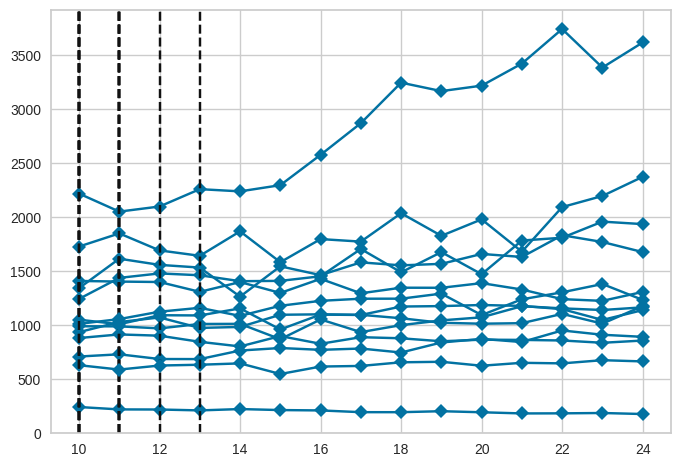

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from yellowbrick.cluster import KElbowVisualizer
from prettytable import PrettyTable
import matplotlib.pyplot as plt

# -----------------------------
# Work on copies of all features
# -----------------------------
X_train_copy = X_train_all.copy()
X_test_copy  = X_test_all.copy()

final_drop_list = []
best_cols = []

table = PrettyTable()
table.field_names = ['Original', 'Final Transformed Feature', 'Accuracy(CV) - Logistic Regression']

threshold = 0.8  # correlation threshold


num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
original_numeric_cols = num_cols  # your original numeric features
all_numeric_cols = X_train_all.select_dtypes(include=['int64', 'float64']).columns

# Derived numeric features are numeric columns not in original numeric list
num_derived_list = [c for c in all_numeric_cols if c not in original_numeric_cols]
# -----------------------------
# Loop over numeric parent features
# -----------------------------
for col in num_cols:
    # 1️⃣ Derived features related to this numeric parent
    sub_set = [f for f in num_derived_list if col in f]
    existing = [f for f in X_train_copy.columns if f in sub_set]
    
    if not existing:
        continue  # skip if no derived features
    
    # 2️⃣ Find highly correlated pairs
    correlated_features = []
    for i, f1 in enumerate(existing):
        for j in range(i + 1, len(existing)):
            if np.abs(X_train_copy[f1].corr(X_train_copy[existing[j]])) > threshold:
                correlated_features.append(existing[j])
    correlated_features = list(set(correlated_features))
    
    if len(correlated_features) > 1:
        # 3️⃣ Scale and impute
        temp_train = X_train_copy[correlated_features].fillna(0)
        temp_test = X_test_copy[correlated_features].fillna(0)
        
        scaler = StandardScaler()
        temp_train_scaled = scaler.fit_transform(temp_train)
        temp_test_scaled  = scaler.transform(temp_test)
        
        # 4️⃣ PCA
        pca = TruncatedSVD(n_components=1, random_state=42)
        x_pca_train = pca.fit_transform(temp_train_scaled)
        x_pca_test  = pca.transform(temp_test_scaled)
        
        pca_col = f"{col}_pca_final"
        X_train_copy[pca_col] = x_pca_train
        X_test_copy[pca_col]  = x_pca_test
        
        # 5️⃣ Clustering
        model = KMeans(random_state=42)
        visualizer = KElbowVisualizer(model, k=(10, 25), metric='calinski_harabasz', timings=False)
        visualizer.fit(temp_train_scaled)
        ideal_clusters = visualizer.elbow_value_ or 10
        kmeans = KMeans(n_clusters=ideal_clusters, random_state=42)
        kmeans.fit(temp_train_scaled)
        labels_train = kmeans.labels_
        labels_test  = kmeans.predict(temp_test_scaled)
        
        cluster_col = f"{col}_cluster_final"
        cluster_mean = np.log1p(
            pd.DataFrame({
                'cluster': labels_train,
                'target': y_train_int.values.ravel()  # <-- flatten to 1D
            })
            .groupby('cluster')['target']
            .mean()
        )
        cluster_dict = cluster_mean.to_dict()
        X_train_copy[cluster_col] = pd.Series(labels_train).map(cluster_mean.to_dict()).fillna(0)
        X_test_copy[cluster_col]  = pd.Series(labels_test).map(cluster_mean.to_dict()).fillna(0)

        
        # 6️⃣ Evaluate features using CV Logistic Regression
        eval_features = correlated_features + [pca_col, cluster_col]
        acc_list = []
        for f in eval_features:
            X_feat = X_train_copy[[f]].fillna(0).values
            y_array = y_train_int.values.ravel()
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_acc = []
            for train_idx, val_idx in kf.split(X_feat, y_array):
                X_tr, X_val = X_feat[train_idx], X_feat[val_idx]
                y_tr, y_val = y_array[train_idx], y_array[val_idx]
                model = LogisticRegression()
                model.fit(X_tr, y_tr)
                y_pred = model.predict_proba(X_val)[:, 1]
                cutoff = acc_cutoff(y_val, y_pred)
                y_pred_bin = (y_pred > cutoff).astype(int)
                cv_acc.append(accuracy_score(y_val, y_pred_bin))
            acc_list.append((f, np.mean(cv_acc)))
        
        # 7️⃣ Select best feature
        best_col, best_acc = sorted(acc_list, key=lambda x: x[1], reverse=True)[0]
        best_cols.append(best_col)
        
        # Drop other correlated features
        drop_cols = [f for f in eval_features if f != best_col]
        final_drop_list += drop_cols
        
        table.add_row([col, best_col, best_acc])
    else:
        table.add_row([col, "All features selected", "--"])

print(table)
print("Features to drop:", final_drop_list)

# -----------------------------
# Drop the other correlated features from copies
# -----------------------------
X_train_final = X_train_copy.drop(columns=final_drop_list)
X_test_final  = X_test_copy.drop(columns=final_drop_list)

print(f"Final dataset shape after correlated feature elimination: {X_train_final.shape}")


**Method 3: based on feature Importance**

In [195]:
#

### Feature Selection (RFE-CV)

RFECV is a technique for automated feature selection that combines recursive feature elimination and cross-validation to identify the optimal subset of features for a given machine learning task.

<mark>Note: RFE-CV takes a lot of time. Here n_estimators are reduced to save time. When originally used, it is recommended to run with the actual hyperparameters.</mark>

**When might you still use RFECV?**
- You have very few features (<50) and want guaranteed univariate elimination.
- You’re using a non-tree model like linear/logistic regression or SVM.

In [ ]:
import numpy as np
import pandas as pd
from copy import deepcopy
from sklearn.feature_selection import RFECV

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


def rfecv_feature_selection(
    X_train,
    y_train,
    scoring="roc_auc",
    min_features_to_select=10,
    step=1,
    cv=2,
    consensus_threshold=2,
    random_state=42,
    verbose=True
):

    # ----------------------------
    # Define models
    # ----------------------------

    models = {
        "xgb": XGBClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1,
            tree_method="hist",
            eval_metric="logloss"
        ),

        "lgb": LGBMClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        ),

        "cat": CatBoostClassifier(
            iterations=200,
            random_state=random_state,
            verbose=False
        )
    }

    # Work on copies (important)
    X = X_train.copy()
    y = y_train.copy()

    results = {}
    all_removed = []

    # ----------------------------
    # Run RFECV for each model
    # ----------------------------

    for name, model in models.items():

        if verbose:
            print(f"\n{'='*60}")
            print(f"Running RFECV for {name}")
            print(f"{'='*60}")

        selector = RFECV(
            estimator=model,
            step=step,
            min_features_to_select=min_features_to_select,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        selector.fit(X, y)

        support_mask = selector.get_support()

        selected_features = list(X.columns[support_mask])
        removed_features = list(X.columns[~support_mask])

        idx = np.argmax(selector.cv_results_["mean_test_score"])

        mean_score = selector.cv_results_["mean_test_score"][idx]
        std_score = selector.cv_results_["std_test_score"][idx]

        if verbose:
            print(f"Best {scoring}: {mean_score:.5f} ± {std_score:.5f}")
            print(f"Selected features: {len(selected_features)}")
            print(f"Removed features: {removed_features}")

        results[name] = {
            "rfecv_model": deepcopy(selector),
            "selected_features": selected_features,
            "removed_features": removed_features,
            "best_score_mean": mean_score,
            "best_score_std": std_score
        }

        all_removed.extend(removed_features)

    # ----------------------------
    # Consensus Feature Removal
    # ----------------------------

    features, counts = np.unique(all_removed, return_counts=True)

    drop_features = list(features[counts >= consensus_threshold])

    if verbose:
        print("\n" + "="*60)
        print("Consensus Feature Removal")
        print("="*60)
        print(f"Features recommended to drop (>= {consensus_threshold} models):")
        print(drop_features)

    return results, drop_features


def plot_recursive_feature_elimination(elimination, scoring, min_features_to_select, name):
    """
    Plot RFECV results: mean test score ± std for number of features selected.
    """
    n_scores = len(elimination.cv_results_["mean_test_score"])
    plt.figure(figsize=(10, 4))
    plt.xlabel("Number of features selected")
    plt.ylabel(f"{scoring}")

    plt.errorbar(
        range(min_features_to_select, n_scores + min_features_to_select),
        elimination.cv_results_["mean_test_score"],
        yerr=elimination.cv_results_["std_test_score"],
        fmt='o-',
        capsize=3,
        markersize=4,
    )

    plt.title(f"{name} Recursive Feature Elimination", fontweight='bold')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
results, drop_features = rfecv_feature_selection(
    X_train,
    y_train,
    scoring="roc_auc",
    min_features_to_select=10,
    cv=2
)


# Plot RFECV results for each model
for name, res in results.items():
    plot_recursive_feature_elimination(
        res["rfecv_model"],
        scoring="roc_auc",
        min_features_to_select=10,
        name=name
    )
# X_train_selected = X_train.drop(columns=drop_features)
# X_test_selected  = X_test.drop(columns=drop_features)

# results["xgb"]["removed_features"]
# results["lgb"]["selected_features"]
# results["cat"]["best_score_mean"]


Running RFECV for xgb
Best roc_auc: 0.95027 ± 0.00153
Selected features: 12
Removed features: ['RNF']

Running RFECV for lgb
[LightGBM] [Info] Number of positive: 1074, number of negative: 67140
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 944
[LightGBM] [Info] Number of data points in the train set: 68214, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015745 -> initscore=-4.135390
[LightGBM] [Info] Start training from score -4.135390
[LightGBM] [Info] Number of positive: 1074, number of negative: 67141
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

### Iterative Feature Elimination with Model Importance.

**This is 10–100x faster than RFECV.**

better for large data with many features


Here’s why:

1. **RFECV is slow**

   * It trains the model from scratch **once per feature per fold**.
   * With hundreds of features and 5-fold CV, it becomes painfully slow.

2. **RFECV is unstable with tree-based models**

   * Tree models (LightGBM, CatBoost, XGBoost) already have internal feature importance.
   * RFECV can sometimes drop important features because of CV randomness.

3. **Importance-based elimination is faster and more stable**

   * You train **once per iteration**, drop worst features based on importance, and repeat.
   * Works especially well with **ensembles or stacking**, because you can keep OOF predictions stable.

4. **Top Kaggle competitors rarely use RFECV**

   * They prefer **model-based iterative pruning** (sometimes combined with SHAP values).


In [6]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score


def iterative_feature_selection(
    X_train,
    y_train,
    scoring="roc_auc",
    drop_fraction=0.2,
    min_features=20,
    cv=5,
    random_state=42
):
    
    X = X_train.copy()
    current_features = list(X.columns)

    history = []

    while len(current_features) > min_features:

        model = LGBMClassifier(
            n_estimators=500,
            random_state=random_state,
            n_jobs=-1
        )

        score = cross_val_score(
            model,
            X[current_features],
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        ).mean()

        model.fit(X[current_features], y_train)

        importance = pd.Series(
            model.feature_importances_,
            index=current_features
        ).sort_values()

        history.append({
            "n_features": len(current_features),
            "score": score
        })

        print(f"Features: {len(current_features)} | CV {scoring}: {score:.5f}")

        # determine number to drop
        n_drop = max(1, int(len(current_features) * drop_fraction))

        worst_features = importance.index[:n_drop].tolist()

        print("Dropping:", worst_features[:5], "...")

        current_features = [
            f for f in current_features if f not in worst_features
        ]

    return current_features, history

In [7]:
selected_features, history = iterative_feature_selection(
    X_train,
    y_train,
    drop_fraction=0.15,
    min_features=5
)

[LightGBM] [Info] Number of positive: 1719, number of negative: 107424
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 109143, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015750 -> initscore=-4.135041
[LightGBM] [Info] Start training from score -4.135041
[LightGBM] [Info] Number of positive: 1718, number of negative: 107425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Number of positive: 1718, number of negative: 107425
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points i

In [12]:
selected_features

['id',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

### Boruta feature elimination
Boruta is an all-relevant feature selection method, meaning it tries to find all features that are useful for predicting the target, not just a minimal set.

It works with tree-based models like RandomForest because it uses the model’s feature importance scores to decide which features matter.

**Why Use Boruta**

- Boruta is robust because it doesn’t just pick a minimal set—it finds all features that matter.

- Great for datasets with many features, especially when you’re unsure which ones are truly relevant.

- Works well in high-dimensional data like genomics, finance, or marketing datasets.


<mark>Tip: Boruta works best with tree-based models like Random Forest, ExtraTrees, or Gradient Boosting because it relies on feature importance. Using it with linear models doesn’t make sense.</mark>



It is worth playing with RFC parameters. Boruta parameters are explained here https://github.com/scikit-learn-contrib/boruta_py.

In [40]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200, n_jobs=4, class_weight='balanced', max_depth=6)
boruta_selector = BorutaPy(rfc, n_estimators='auto', verbose=2)
boruta_selector.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	13
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	13
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	13
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	13
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	13
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	13
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	13
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	9 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	10 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	11 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	12 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	13 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	14 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	15 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration: 	16 / 100
Confirmed: 	7
Tentative: 	3
Rejected: 	3
Iteration:

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=6,
                                          n_estimators=70, n_jobs=4,
                                          random_state=RandomState(MT19937) at 0x7F91401ECB40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7F91401ECB40, verbose=2)

In [41]:
# Get boolean mask of selected features
selected_mask = boruta_selector.support_

# Column names of selected features
selected_features = X_train.columns[selected_mask]
print("Selected Features:", selected_features)


Selected Features: Index(['Pclass', 'Sex', 'Fare', 'relatives', 'Deck', 'Title', 'Age_Class'], dtype='object')


In [42]:
# Boolean mask of confirmed features
selected_mask = boruta_selector.support_

# Boolean mask of tentative features
tentative_mask = boruta_selector.support_weak_

# Feature rankings: lower is better (1 = selected)
feature_ranks = boruta_selector.ranking_

# Create a DataFrame to see feature name, rank, and selection
feature_ranking_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': feature_ranks,
    'Selected': selected_mask
})

# Sort by rank
feature_ranking_df = feature_ranking_df.sort_values(by='Rank')

print(feature_ranking_df)


            Feature  Rank  Selected
0            Pclass     1      True
1               Sex     1      True
5              Fare     1      True
7         relatives     1      True
9              Deck     1      True
10            Title     1      True
11        Age_Class     1      True
3             SibSp     2     False
2               Age     3     False
12  Fare_Per_Person     3     False
6          Embarked     5     False
4             Parch     6     False
8         not_alone     7     False


features that are not clearly important or unimportant:

In [43]:
tentative_mask = boruta_selector.support_weak_
tentative_features = X_train.columns[tentative_mask]
print("Tentative Features:", tentative_features)


Tentative Features: Index([], dtype='object')


In [44]:
# Transform while keeping as DataFrame
X_train_filtered = boruta_selector.transform(X_train, return_df=True)
X_test_filtered = boruta_selector.transform(X_test, return_df=True)

print("Columns kept:", X_train_filtered.columns.tolist())


IndexError: Boolean index has wrong length: 13 instead of 14

#  Less Important Features


There are a lot of features created and many of them are not important/highly correlated, the first level of reduction is to create subsets based on the original features, apply PCA to select PC1 and drop the subset

💡 Summary of what this code does:

- For each numeric column in cont_cols, find all its “unimportant features” in unimportant_features.

- Scale them using StandardScaler.

- Reduce them to 1 combined feature using TruncatedSVD (similar to PCA).

- Add this new combined feature to your train and test datasets.

- Drop the original unimportant features to reduce dimensionality.

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import TruncatedSVD
# from prettytable import PrettyTable

# # -----------------------------
# # Work on copies of train/test
# # -----------------------------
# X_train_copy = X_train_all.copy()
# X_test_copy  = X_test_all.copy()

# final_drop_list = []  # to store unimportant features that will be dropped
# new_pca_cols = []     # to store new PCA features created

# table = PrettyTable()
# table.field_names = ['Original Parent Feature', 'PCA Feature Created']

# # -----------------------------
# # Define continuous columns
# # -----------------------------
# cont_cols = X_train_all.select_dtypes(include=['int64', 'float64']).columns.tolist()

# # -----------------------------
# # Loop over continuous parent features
# # -----------------------------
# for col in cont_cols:
#     # 1️⃣ Find all unimportant features related to this parent
#     sub_set = [f for f in unimportant_features if col in f]
#     existing = [f for f in X_train_copy.columns if f in sub_set]
    
#     if not existing:
#         continue  # skip if no features to combine
    
#     # 2️⃣ Scale features
#     temp_train = X_train_copy[existing].fillna(0)
#     temp_test  = X_test_copy[existing].fillna(0)
    
#     scaler = StandardScaler()
#     temp_train_scaled = scaler.fit_transform(temp_train)
#     temp_test_scaled  = scaler.transform(temp_test)
    
#     # 3️⃣ Apply TruncatedSVD to reduce to 1 component
#     svd = TruncatedSVD(n_components=1, random_state=42)
#     x_pca_train = svd.fit_transform(temp_train_scaled)
#     x_pca_test  = svd.transform(temp_test_scaled)
    
#     # 4️⃣ Add PCA feature to train/test
#     pca_col = f"{col}_pca_comb_unimp"
#     X_train_copy[pca_col] = x_pca_train
#     X_test_copy[pca_col]  = x_pca_test
#     new_pca_cols.append(pca_col)
    
#     # 5️⃣ Drop original unimportant features (except the parent continuous column)
#     for f in sub_set:
#         if f in X_train_copy.columns and f not in cont_cols:
#             X_train_copy.drop(columns=[f], inplace=True)
#             X_test_copy.drop(columns=[f], inplace=True)
#             final_drop_list.append(f)
    
#     table.add_row([col, pca_col])

# # -----------------------------
# # Display results
# # -----------------------------
# print(table)
# print("Original unimportant features dropped:", final_drop_list)
# print("New PCA features created:", new_pca_cols)
# print(f"Final train shape: {X_train_copy.shape}, test shape: {X_test_copy.shape}")


+-------------------------+---------------------+
| Original Parent Feature | PCA Feature Created |
+-------------------------+---------------------+
+-------------------------+---------------------+
Original unimportant features dropped: []
New PCA features created: []
Final train shape: (6954, 101), test shape: (1739, 101)


# PCA

Just for fun, let's look at the transformed data in PCA space. This gives a low dimensional representation of the data, which preserves local and global structure.


In [45]:
from sklearn.decomposition import PCA
import plotly.express as px

# 1️⃣ Select numeric features only
numeric_cols = X_train_all.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train_all[numeric_cols]

# 2️⃣ Apply PCA
pca = PCA(n_components=3)
components = pca.fit_transform(X_train_numeric)

total_var = pca.explained_variance_ratio_.sum() * 100

# 3️⃣ 3D scatter plot
fig = px.scatter_3d(
    x=components[:, 0],
    y=components[:, 1],
    z=components[:, 2],
    color=y_train_enc,  # target
    size=0.1*np.ones(len(X_train_numeric)),
    opacity=1,
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'x': 'PC 1', 'y': 'PC 2', 'z': 'PC 3'},
    width=800, height=500
)
fig.show()


ValueError: Input X contains NaN, infinity or a value too large for dtype('float64').

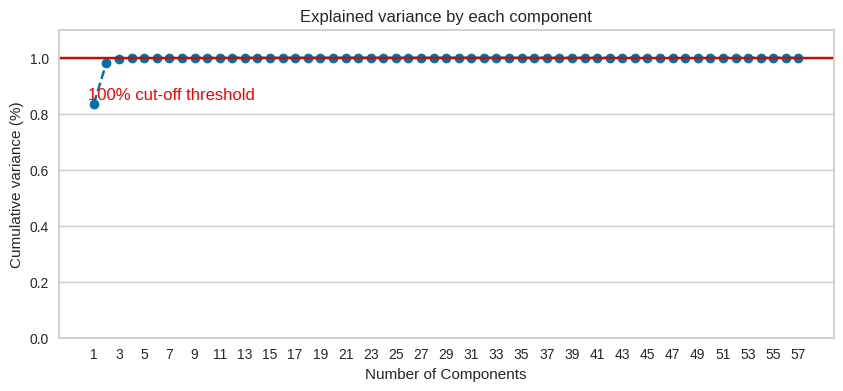

In [209]:
# Explained variance (how important each additional principal component is)
pca = PCA().fit(X_train_numeric)
fig, ax = plt.subplots(figsize=(10,4))
xi = np.arange(1, 1+X_train_numeric.shape[1], step=1)
yi = np.cumsum(pca.explained_variance_ratio_)
plt.plot(xi, yi, marker='o', linestyle='--', color='b')

# Aesthetics
plt.ylim(0.0,1.1)
plt.xlabel('Number of Components')
plt.xticks(np.arange(1, 1+X_train_numeric.shape[1], step=2))
plt.ylabel('Cumulative variance (%)')
plt.title('Explained variance by each component')
plt.axhline(y=1, color='r', linestyle='-')
plt.text(0.5, 0.85, '100% cut-off threshold', color = 'red')
ax.grid(axis='x')

**RFE with xgboosst**

In [ ]:


from sklearn.feature_selection import RFECV
import xgboost as xgb



X_train, X_val, y_train, y_val = train_test_split(X_train, y_train_int, test_size=0.2, random_state=42, stratify=y)

model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    random_state=42,
    eval_metric='mlogloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=model_xgb,
    step=1,
    cv=cv,
    scoring='accuracy',
    min_features_to_select=5
)

rfecv.fit(X_train, y_train)

# Plot RFECV performance
plt.figure(figsize=(8, 5))
plt.title("RFECV - Number of Features vs CV Accuracy")
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated Accuracy")
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    rfecv.cv_results_['mean_test_score'],
    marker='o'
)
plt.show()

selected_features = X_train.columns[rfecv.support_]
print("Selected Features:")
print(selected_features)



In [ ]:
X_train_all.to_csv('../data/X_train_fg.csv', index=False)
X_test_all.to_csv('../data/X_test_fg.csv', index=False)
y_train.to_csv('../data/y_train_fg.csv', index=False)
y_test.to_csv('../data/y_test_fg.csv', index=False)
